# Tarea 2: DSP Exercise Set: Correlation & Cross-Correlation

Materia: Procesamiento Digital de Señales

Grupo: 03

Equipo: 02

### Integrantes:
* Espinoza Matamoros Percival Ulises
* Lugo Manzano Rodrigo
* García Cortés Adolfo de Jésus

## Link Video Explicación [PENDIENTE]
[Video Explicando la Tarea1](https://www.youtube.com/watch?v=epkC8jQnW58)


## Importacion y Configuracion Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 3)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)

In [2]:
# Funciones para realizar la autocorrelacion y correlacion

# Autocorrelacion (r_{xx})
def autocorrelacion_discreto(xn,lag):
  # x[:-lag] -> (x[n])
  # x[lag:]  -> (x[n + lag])
  lag = int(abs(lag))
  N = len(xn)

  if lag == 0:
      r_xx = (xn @ xn)
  else:
      r_xx = (xn[:-lag] @ xn[lag:])

  return r_xx

def autocorrelacion_continuo(xn,lag):
  lag = int(abs(lag))
  N = len(xn)

  if lag == 0:
    r_xx = (xn @ xn) / N
  elif lag < N:
    puntos_superpuestos = N - lag
    r_xx = (xn[:-lag] @ xn[lag:]) / puntos_superpuestos
  else:
    r_xx = 0.0

  return r_xx

def correlacion_cruzada(xn, yn):
  #Seleccionando Elementos Utiles
  i_xn = np.nonzero(xn)[0]
  i_yn = np.nonzero(yn)[0]

  if len(i_xn) == 0 or len(i_yn) == 0:
      return np.array([0]), np.array([0])

  inicio_x_orig = i_xn[0]
  inicio_y_orig = i_yn[0]

  xn_u = xn[inicio_x_orig : i_xn[-1] + 1]
  yn_u = yn[inicio_y_orig : i_yn[-1] + 1]

  N = len(xn_u)
  M = len(yn_u)

  lags_temporales = np.arange(-(M - 1), N)

  #Ajuste de los retardos reales
  ajuste_tiempo = inicio_x_orig - inicio_y_orig
  lags_reales = lags_temporales + ajuste_tiempo

  tipo_dato = np.result_type(xn, yn)
  R_xy = np.zeros(len(lags_temporales), dtype=tipo_dato)

  for i, k_rel in enumerate(lags_temporales):
      inicio_xn = max(0, k_rel)
      fin_xn = min(N, M + k_rel)

      inicio_yn = max(0, -k_rel)
      fin_yn = min(M, N - k_rel)

      # rxy = Σ (x[n]) * (y[n - k])
      R_xy[i] = xn_u[inicio_xn:fin_xn] @ yn_u[inicio_yn:fin_yn]

  return lags_reales, R_xy

def correlacion_cruzada_continuo(xn, yn):
    # Seleccionando Elementos Útiles
    i_xn = np.nonzero(xn)[0]
    i_yn = np.nonzero(yn)[0]

    if len(i_xn) == 0 or len(i_yn) == 0:
        return np.array([0]), np.array([0])

    inicio_x_orig = i_xn[0]
    inicio_y_orig = i_yn[0]

    xn_u = xn[inicio_x_orig : i_xn[-1] + 1]
    yn_u = yn[inicio_y_orig : i_yn[-1] + 1]

    N = len(xn_u)
    M = len(yn_u)

    lags_temporales = np.arange(-(M - 1), N)

    # Ajuste de los retardos reales
    ajuste_tiempo = inicio_x_orig - inicio_y_orig
    lags_reales = lags_temporales + ajuste_tiempo

    tipo_dato = np.result_type(xn, yn)
    R_xy = np.zeros(len(lags_temporales), dtype=tipo_dato)

    for i, k_rel in enumerate(lags_temporales):
        inicio_xn = max(0, k_rel)
        fin_xn = min(N, M + k_rel)

        inicio_yn = max(0, -k_rel)
        fin_yn = min(M, N - k_rel)

        # Puntos Utilzados debido a la ventana
        puntos_superpuestos = fin_xn - inicio_xn

        # rxy = (Σ (x[n]) * (y[n - k])) / puntos_superpuestos
        if puntos_superpuestos > 0:
            R_xy[i] = (xn_u[inicio_xn:fin_xn] @ yn_u[inicio_yn:fin_yn]) / puntos_superpuestos
        else:
            R_xy[i] = 0.0

    return lags_reales, R_xy

def correlacion_continua_magnitud(xn, yn):
  if len(xn) == 0 or len(yn) == 0 or len(xn) != len(yn):
    return 0.0

  #Corr = (1/T) * integral( x(t) * y(t) dt )
  #Normalizando correlacion
  r_xy_continua = (xn @ yn) / len(xn)

  return r_xy_continua

# Excercise 1: Autocorrelation of a discrete signal
Consider the discrete-time signal

$$x[n] = \{1,2,3,2,1\}, \quad n=0, ..., 4$$


### a) Compute $R_{xx}$ manually

*Resultados obtenidos a mano*

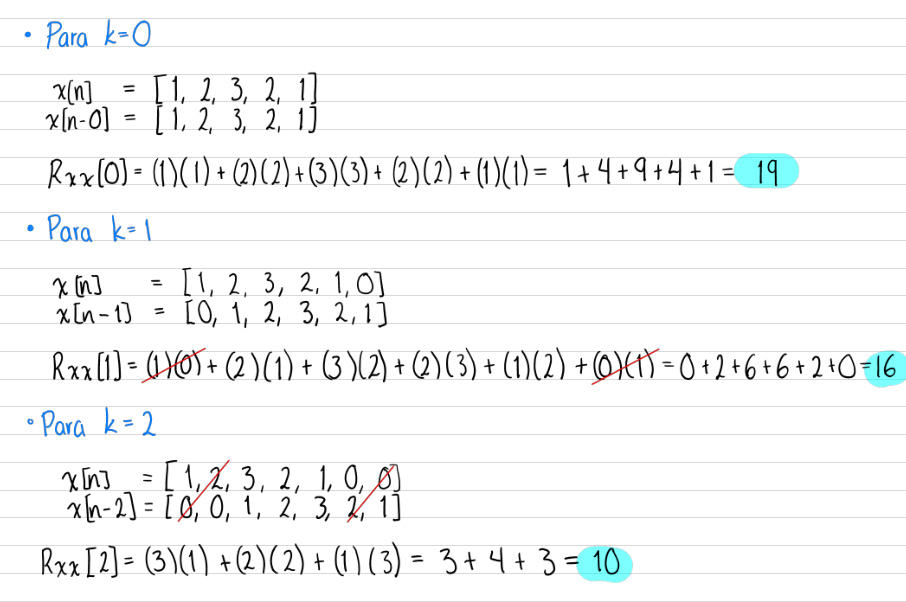



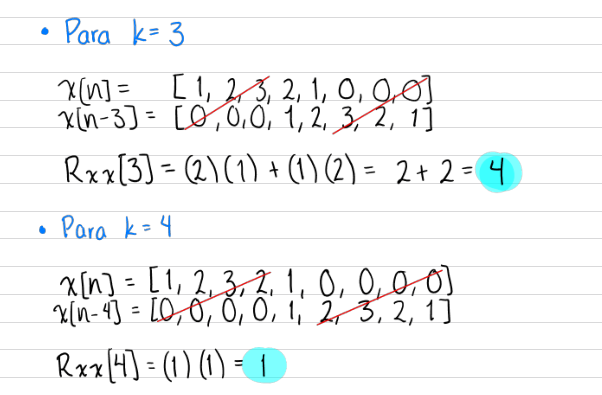

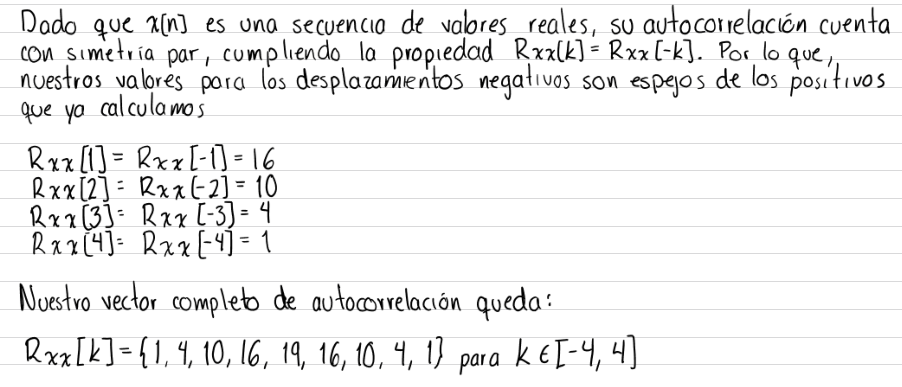

### b) Implement the calculation in Python

In [3]:
# Señal Discreta
xn = np.array([1, 2, 3, 2, 1])
n = np.arange(0,5)
k = np.arange(-4, (4 + 1), 1)

r_xx_list = []
print("<<<< Autocorrelaciones >>>> \n")
for lag in k:
  r_xx = autocorrelacion_discreto(xn, lag)
  r_xx_list.append(r_xx)
  print(f"k = {lag}\t --> R_xx= {r_xx}")

<<<< Autocorrelaciones >>>> 

k = -4	 --> R_xx= 1
k = -3	 --> R_xx= 4
k = -2	 --> R_xx= 10
k = -1	 --> R_xx= 16
k = 0	 --> R_xx= 19
k = 1	 --> R_xx= 16
k = 2	 --> R_xx= 10
k = 3	 --> R_xx= 4
k = 4	 --> R_xx= 1


### c) Plot $x[n]$ and $R_{xx}[k]$

/tmp/ipykernel_69567/2528806915.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_69567/2528806915.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


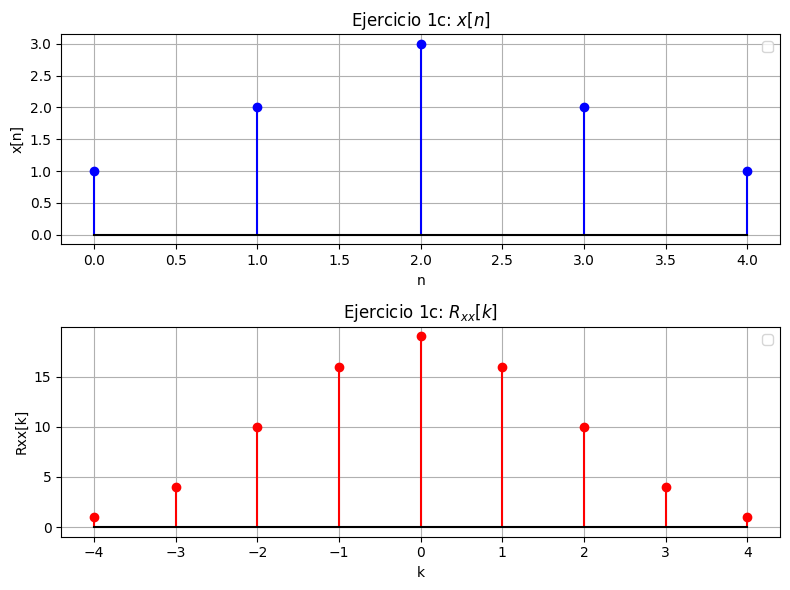

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.stem(n, xn, linefmt='blue', markerfmt='b', basefmt='black')
ax1.set_title(r"Ejercicio 1c: $x[n]$")
ax1.set_xlabel("n")
ax1.set_ylabel("x[n]")
ax1.grid(True)
ax1.legend()

ax2.stem(k, r_xx_list, linefmt='red', markerfmt='ro', basefmt='black')
ax2.set_title(r"Ejercicio 1c: $R_{xx}[k]$")
ax2.set_xlabel("k")
ax2.set_ylabel("Rxx[k]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

*Resultados obtenidos a mano*

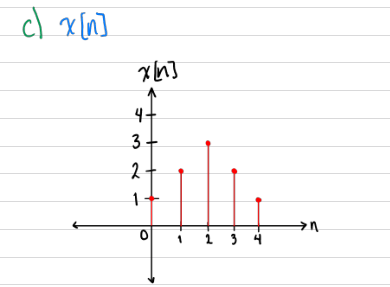

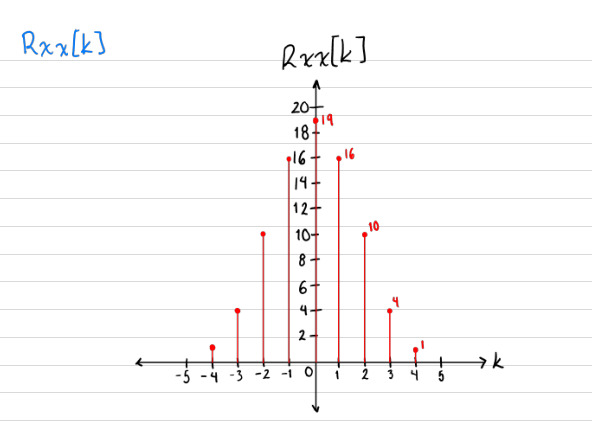

### d) At which lag is the maximum obtained?

In [5]:
max_rxx = max(r_xx_list)
max_lag = k[r_xx_list.index(max_rxx)]

print(f"La mayor correlacion se da cuando k = {max_lag} --> Rxx[{max_lag}] = {max_rxx}")

La mayor correlacion se da cuando k = 0 --> Rxx[0] = 19


### e) Describe the symetry observed in the autocorrelation

La autocorrelación de estas dos señales tiene simetría temporal par, matemáticamente como $\phi_{xx}[n] = \phi_{xx}-[n]$.

Esto en la gráfica se puede ver la reflexión espejo alrededor del eje vertical de amplitud cuando el retraso es cero.

# Excercise 2: Cross-correlation and time displacement
Consider
$$x[n] = \{0,1,2,3,2,1,0\}$$
$$y[n] = \{0,0,0,1,2,3,2,1,0\}$$

### a) Plot both signals

/tmp/ipykernel_69567/749694674.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_69567/749694674.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


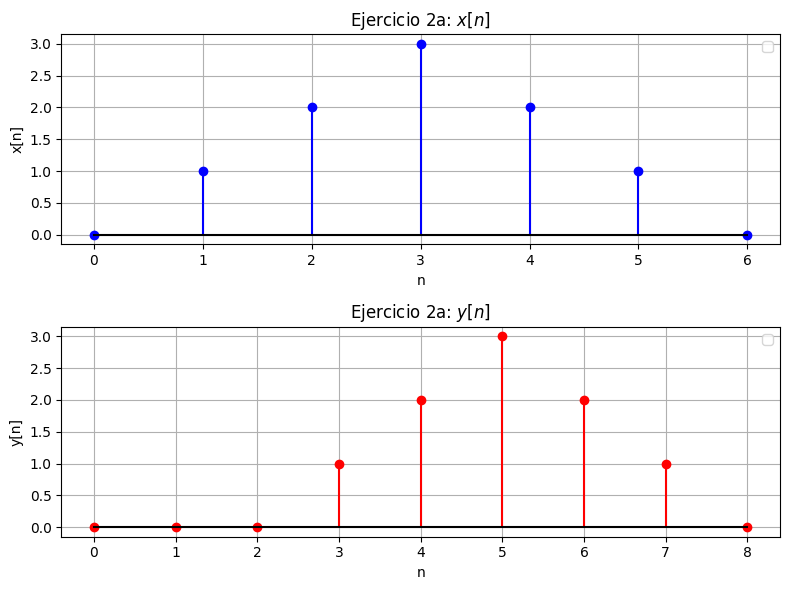

In [6]:
xn = np.array([0,1,2,3,2,1,0])
yn = np.array([0,0,0,1,2,3,2,1,0])
n_x = np.arange(0, len(xn))
n_y = np.arange(0, len(yn))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.stem(n_x, xn, linefmt='blue', markerfmt='b', basefmt='black')
ax1.set_title(r"Ejercicio 2a: $x[n]$")
ax1.set_xlabel("n")
ax1.set_ylabel("x[n]")
ax1.grid(True)
ax1.legend()

ax2.stem(n_y, yn, linefmt='red', markerfmt='ro', basefmt='black')
ax2.set_title(r"Ejercicio 2a: $y[n]$")
ax2.set_xlabel("n")
ax2.set_ylabel("y[n]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

*Resultados obtenidos a mano*

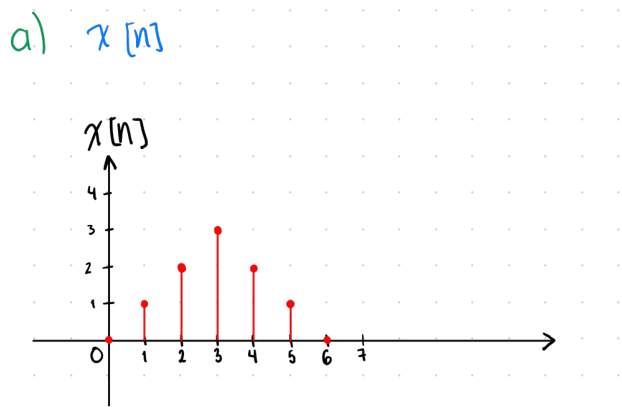

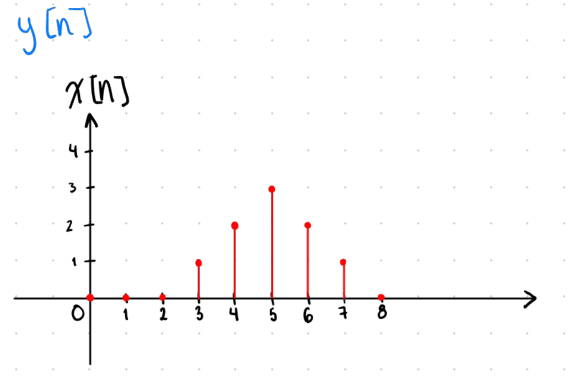

### b) Compute $R_{xy}[k]$

In [7]:
k, rxy = correlacion_cruzada(xn, yn)
print("<<<< Correlación Cruzada >>>> \n")
for i in range(len(k)):
  print(f"k = {k[i]}\t --> Rxy = {rxy[i]}")

<<<< Correlación Cruzada >>>> 

k = -6	 --> Rxy = 1
k = -5	 --> Rxy = 4
k = -4	 --> Rxy = 10
k = -3	 --> Rxy = 16
k = -2	 --> Rxy = 19
k = -1	 --> Rxy = 16
k = 0	 --> Rxy = 10
k = 1	 --> Rxy = 4
k = 2	 --> Rxy = 1


*Resultados obtenidos a mano*

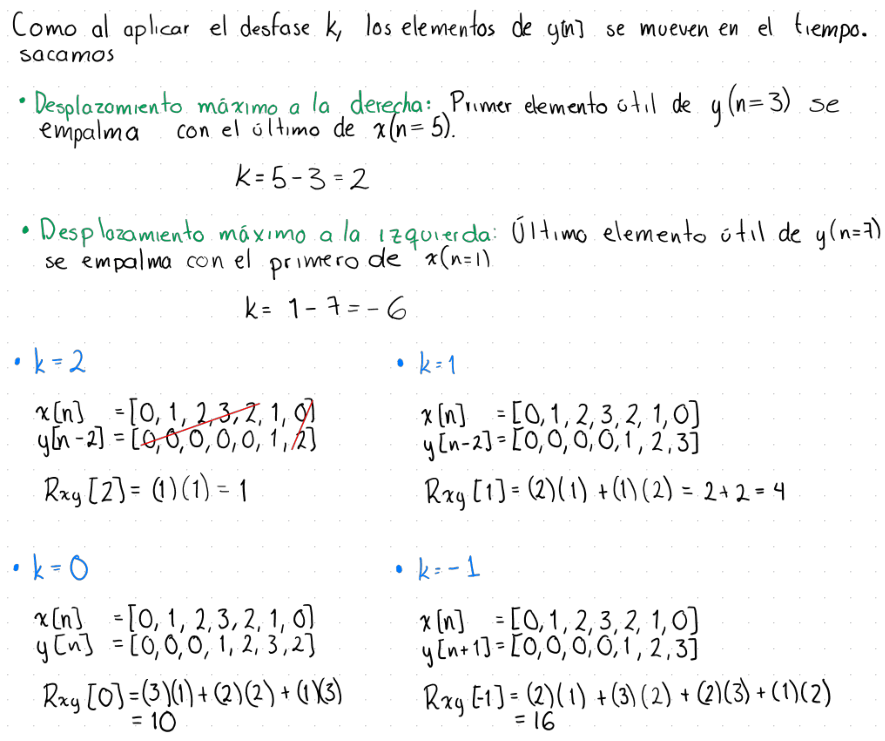

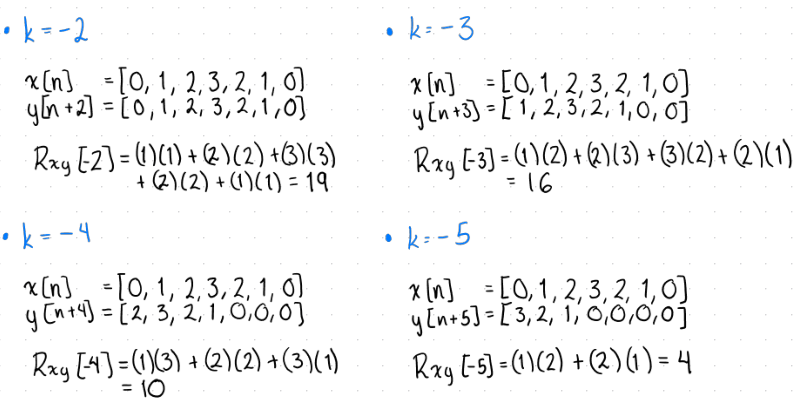

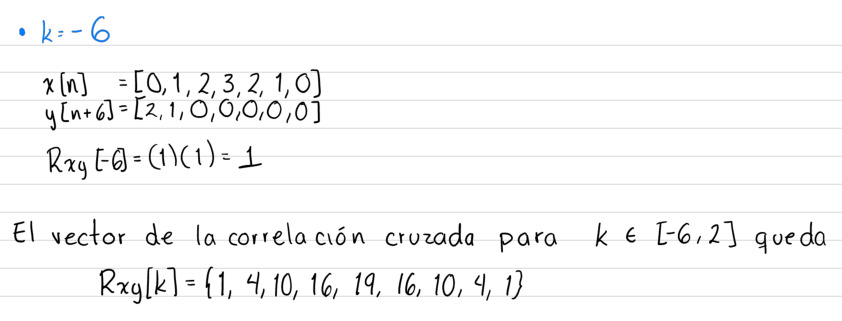

### c) Plot the cross-correlation

/tmp/ipykernel_69567/2471000579.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


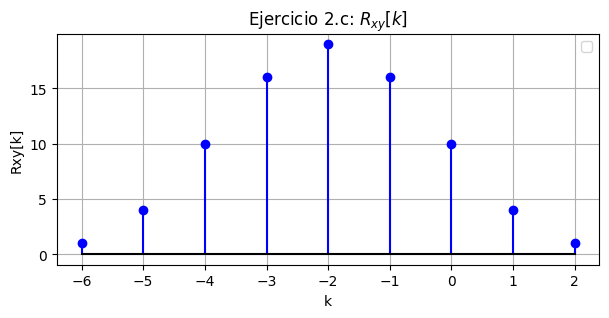

In [8]:
plt.stem(k, rxy, linefmt='blue', markerfmt='b', basefmt='black')
plt.title(r"Ejercicio 2.c: $R_{xy}[k]$")
plt.xlabel("k")
plt.ylabel("Rxy[k]")
plt.grid(True)
plt.legend()
plt.show()

*Resultados obtenidos a mano*

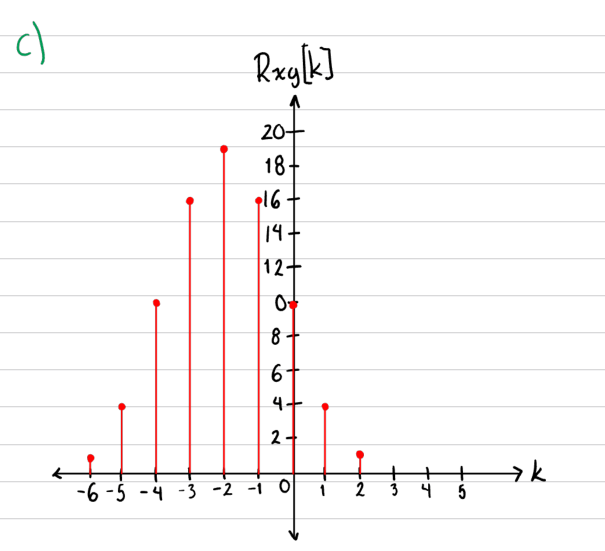

### d) Determine the lag corresponding to its maximum

In [9]:
max_rxx = max(rxy)
max_lag = k[list(rxy).index(max_rxx)]

print(f"La mayor correlacion se da cuando k = {max_lag} --> Rxx[{max_lag}] = {max_rxx}")

La mayor correlacion se da cuando k = -2 --> Rxx[-2] = 19


### e) Explain what this lag tells you about the relative position of the signals

El valor de ($k=2$) donde obtuvimos el máximo absoluto nos dice el desface entre ambas señales. Es decir, la señal $y[n]$ y $x[n]$ son indénticas, pero su ocurrencia esta retrasada por 2 muestras en el timepo. Al evaular la correlación cruzada, el algoritmo require adelantar dos posiciones a la izquierda ($k=-2$) para contrarrestart el retraso, logrando la alineación.

# Excercise 3: Detecting a known pattern
A receiver observes
$$x[n] = \{0,0,1,-1,2,1,-1,0,0\}$$
and searches for the pattern
$$p[n] = \{1,-1,2,1,-1\}$$

### a) Compute the cross-correlation between $x[n]$ and $p[n]$

In [10]:
xn = np.array([0,0,1,-1,2,1,-1,0,0])
pn = np.array([1,-1,2,1,-1])
n_x = np.arange(0, len(xn))
n_p = np.arange(0, len(pn))

k, rxp = correlacion_cruzada(xn, pn)
print("<<<< Correlación Cruzada >>>> \n")
for i in range(len(k)):
  print(f"k = {k[i]}\t --> Rxp = {rxp[i]}")


<<<< Correlación Cruzada >>>> 

k = -2	 --> Rxp = -1
k = -1	 --> Rxp = 2
k = 0	 --> Rxp = -1
k = 1	 --> Rxp = -2
k = 2	 --> Rxp = 8
k = 3	 --> Rxp = -2
k = 4	 --> Rxp = -1
k = 5	 --> Rxp = 2
k = 6	 --> Rxp = -1


*Resultados obtenidos a mano*


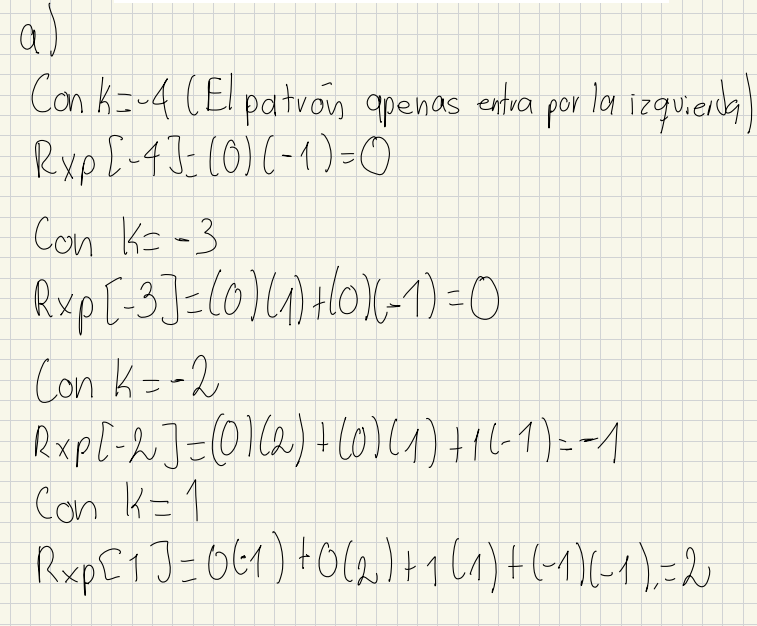

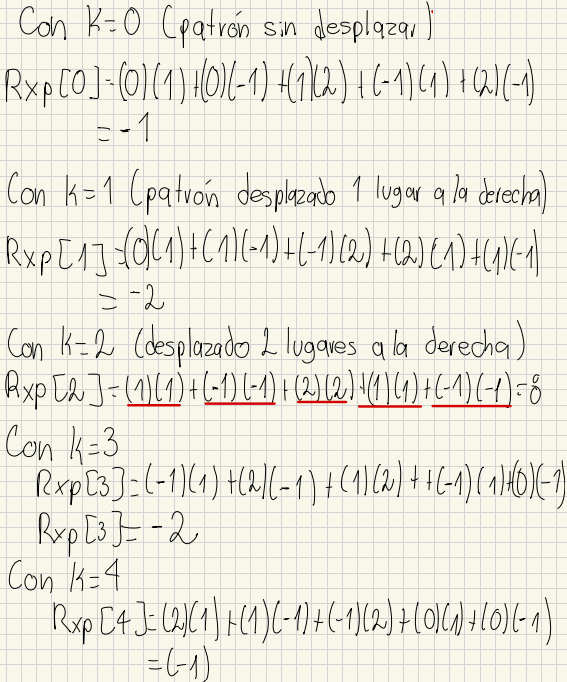

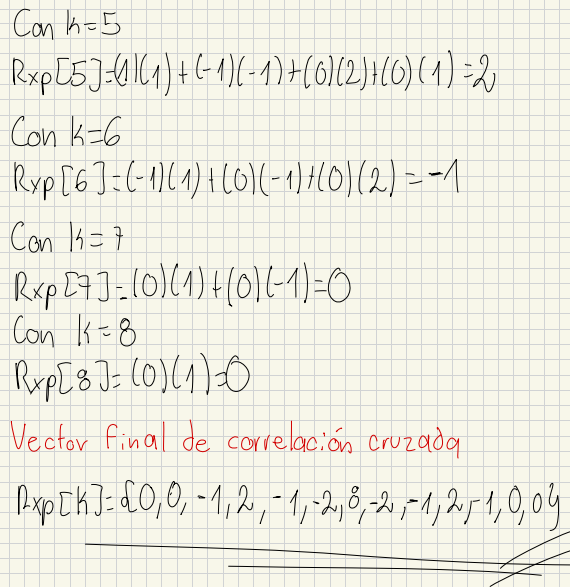

### b) Plot the result

/tmp/ipykernel_69567/1877154477.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


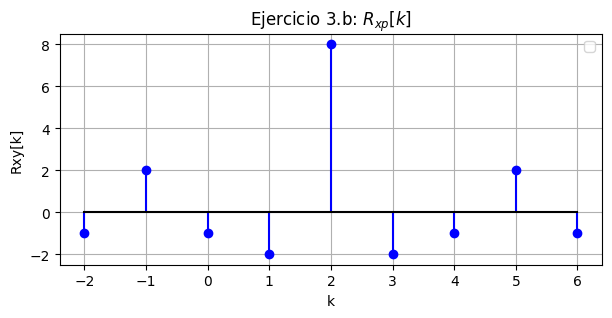

In [11]:
plt.stem(k, rxp, linefmt='blue', markerfmt='b', basefmt='black')
plt.title(r"Ejercicio 3.b: $R_{xp}[k]$")
plt.xlabel("k")
plt.ylabel("Rxy[k]")
plt.grid(True)
plt.legend()
plt.show()

*Resultados obtenidos a mano*


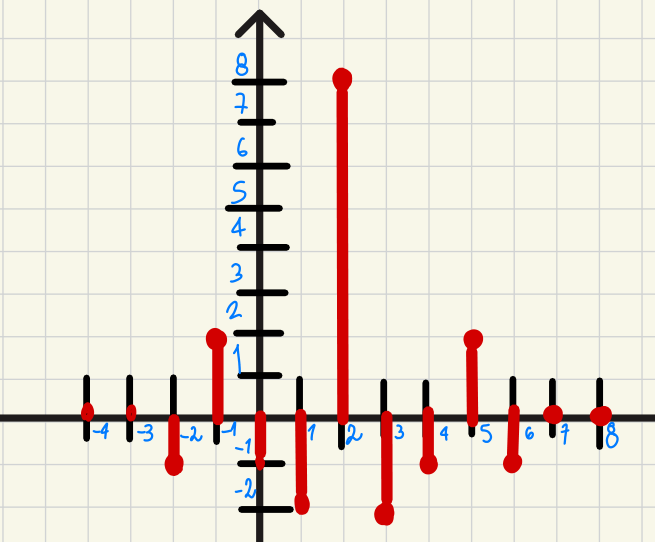

### C) Determine where the pattern occurs in $x[n]$

In [12]:
max_rxp = max(rxp)
max_lag = k[list(rxp).index(max_rxp)]

print(f"La mayor correlacion se da cuando k = {max_lag} --> Rxp[{max_lag}] = {max_rxp}")

La mayor correlacion se da cuando k = 2 --> Rxp[2] = 8


*Resultados obtenidos a mano*


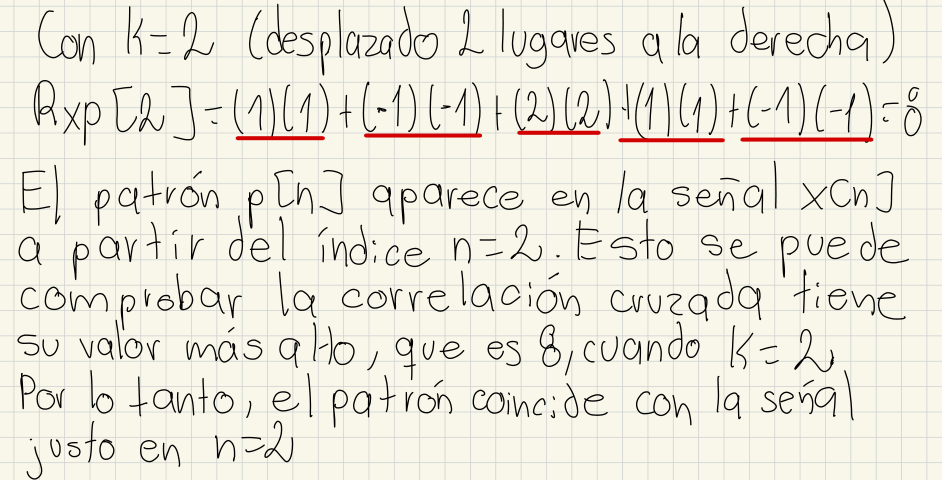

### d) Explain why correlation can be used as a detection mechanism.

La correlación sirve para detectar cuándo un patrón coincide una señal. Cuando el patrón se coloca en una parte donde no coincide, algunos valores se multiplican con signos diferentes, y se cancelan entre sí, por lo que el resultado suele ser cercano a cero o negativo.

En cambio, cuando el patrón llega al punto donde coincide con los mismos datos ($k=2$), los valores tienen el mismo signo y las multiplicaciones dan resultados positivos. Estos valores se suman y producen un pico muy alto, lo que permite identificar facilmente que el patrón esta presente y exactamente donde se encuentra.

# Excercise 4: Autocorrelation of a sinusoid
Generate
$$x(t) = sin(2 \pi \cdot 5t), \quad 0 \leq t \leq 2[s], \quad f_s = 100[Hz] $$


### a) Plot the signal

/tmp/ipykernel_69567/1975867156.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


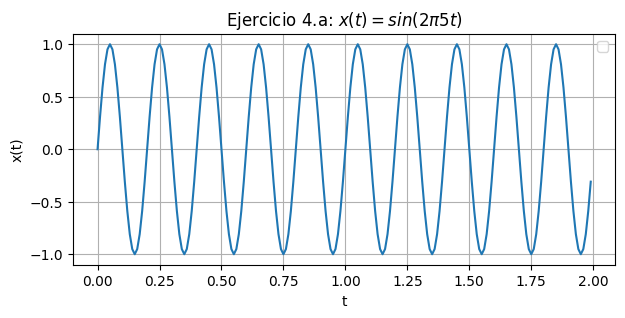

In [13]:
f = 5
s_max = 2
fs = 100
max_lags = s_max * fs
t = np.arange(0, s_max, 1/fs)
x = np.sin(2*np.pi*f*t)

plt.plot(t, x)
plt.title(r"Ejercicio 4.a: $x(t) = sin (2 \pi 5t)$")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.legend()
plt.show()

*Resultados obtenidos a mano*

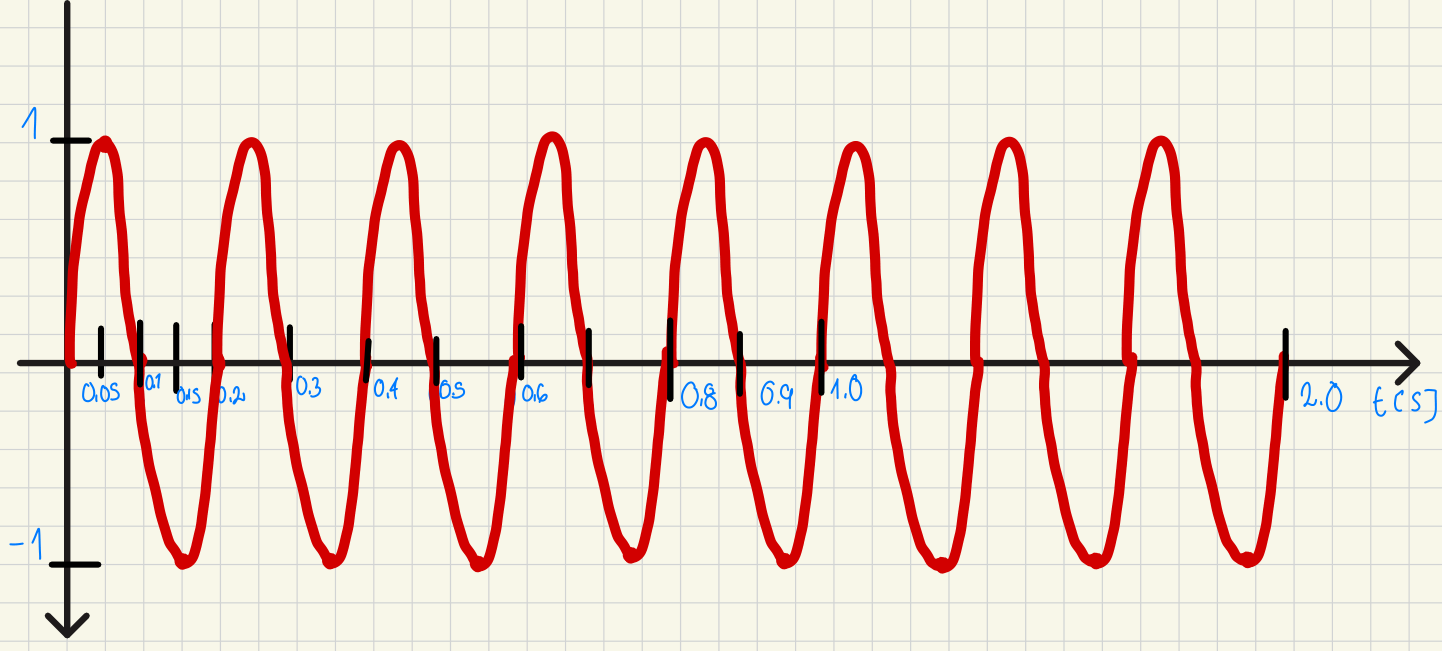

### b) Compute and plot its autocorrelation

In [14]:
max_lags = s_max * fs
lags_enteros = np.arange(0, max_lags + 1)

print("<<<< Correlación Cruzada >>>> \n")
rxx_list = []
for lag in lags_enteros:
    rxx = autocorrelacion_continuo(x, lag)
    print(f"tau = {lag/fs}\t --> Rxp = {rxx}")
    rxx_list.append(rxx)


<<<< Correlación Cruzada >>>> 

tau = 0.0	 --> Rxp = 0.5000000000000001
tau = 0.01	 --> Rxp = 0.4779178473844993
tau = 0.02	 --> Rxp = 0.40907672192074374
tau = 0.03	 --> Rxp = 0.3002121649403553
tau = 0.04	 --> Rxp = 0.16197546398115956
tau = 0.05	 --> Rxp = 0.007891496249167358
tau = 0.06	 --> Rxp = -0.14696455135467765
tau = 0.07	 --> Rxp = -0.2874421124548303
tau = 0.08	 --> Rxp = -0.39979751543128894
tau = 0.09	 --> Rxp = -0.47303858140334865
tau = 0.1	 --> Rxp = -0.49999999999999983
tau = 0.11	 --> Rxp = -0.4780442806774582
tau = 0.12	 --> Rxp = -0.40931971259804545
tau = 0.13	 --> Rxp = -0.3005501081913778
tau = 0.14	 --> Rxp = -0.16237691380877708
tau = 0.15	 --> Rxp = -0.008318063613987195
tau = 0.16	 --> Rxp = 0.14655455429854755
tau = 0.17	 --> Rxp = 0.2870896253678683
tau = 0.18	 --> Rxp = 0.3995386702798502
tau = 0.19	 --> Rxp = 0.47290103020201
tau = 0.2	 --> Rxp = 0.5000000000000001
tau = 0.21	 --> Rxp = 0.47818484059532856
tau = 0.22	 --> Rxp = 0.40959000559863934
tau =

/tmp/ipykernel_69567/776294780.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


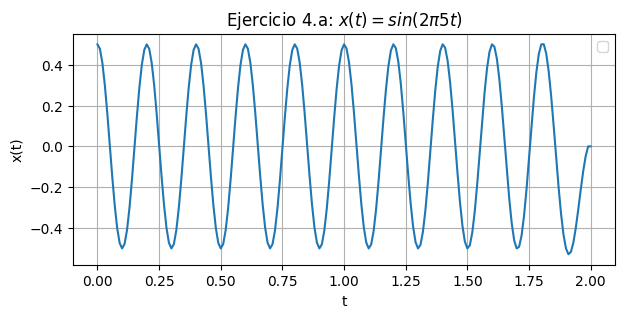

In [15]:
tau = lags_enteros / fs

plt.plot(tau,rxx_list)
plt.title(r"Ejercicio 4.a: $x(t) = sin (2 \pi 5t)$")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.legend()
plt.show()

*Resultados obtenidos a mano*

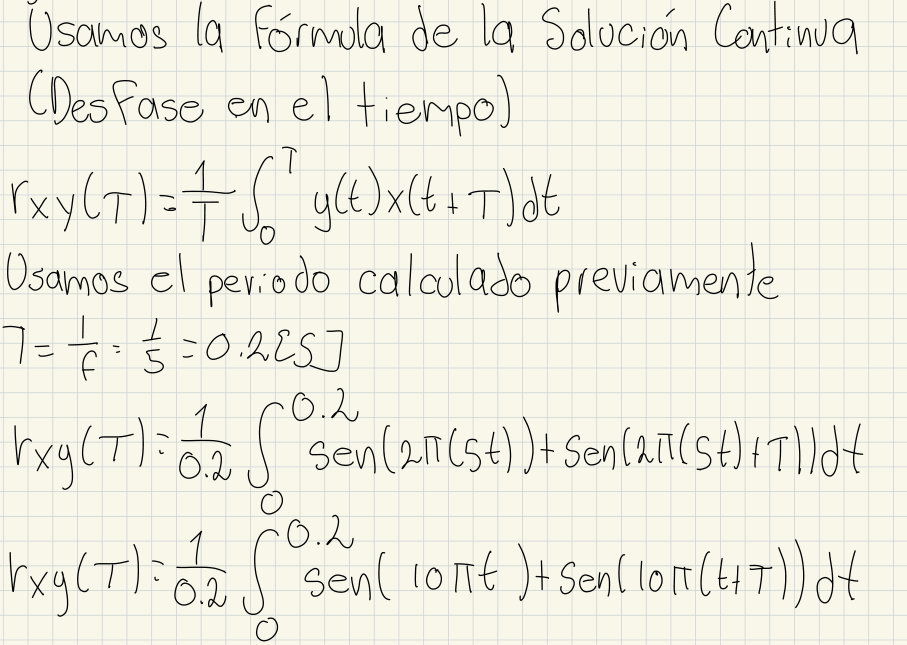

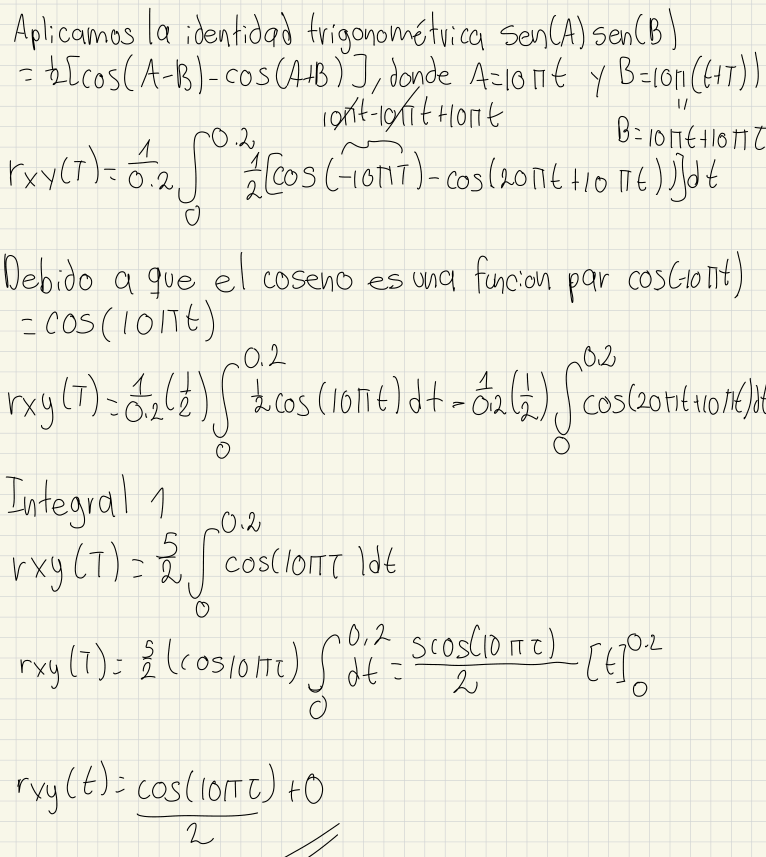

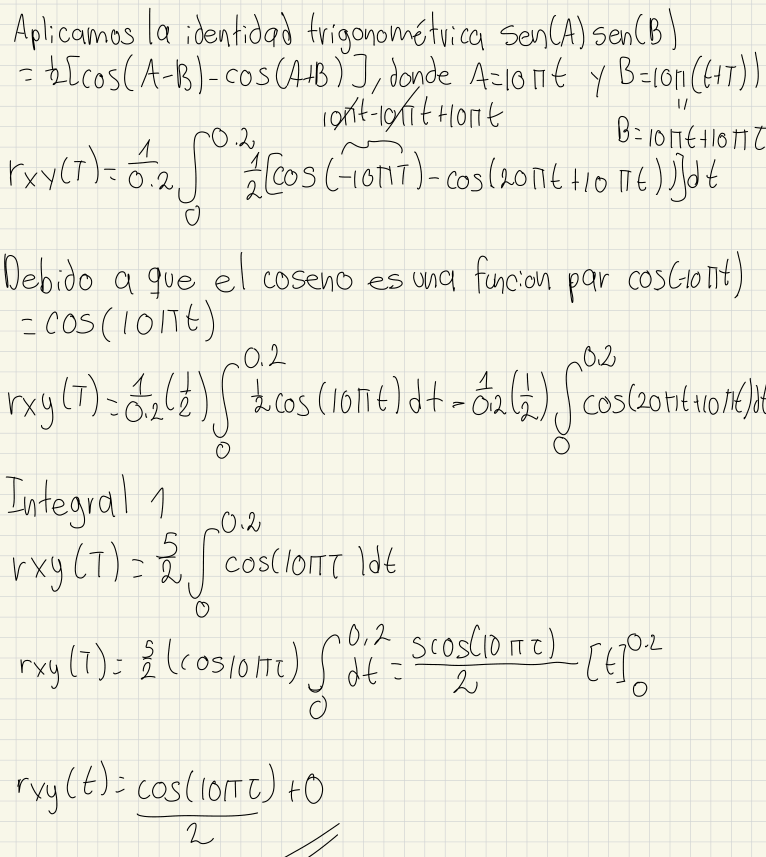

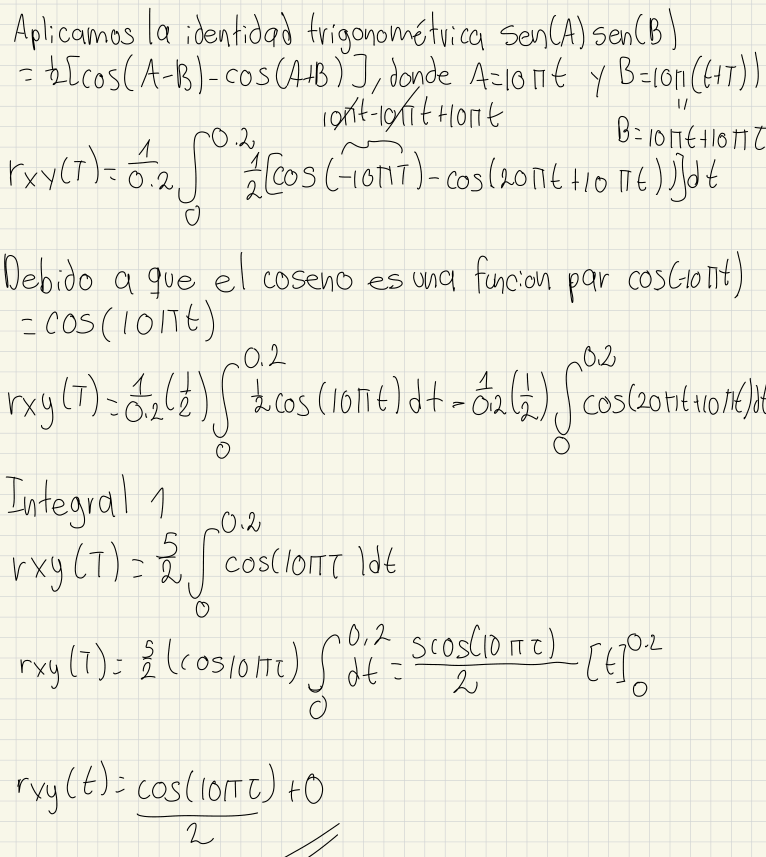

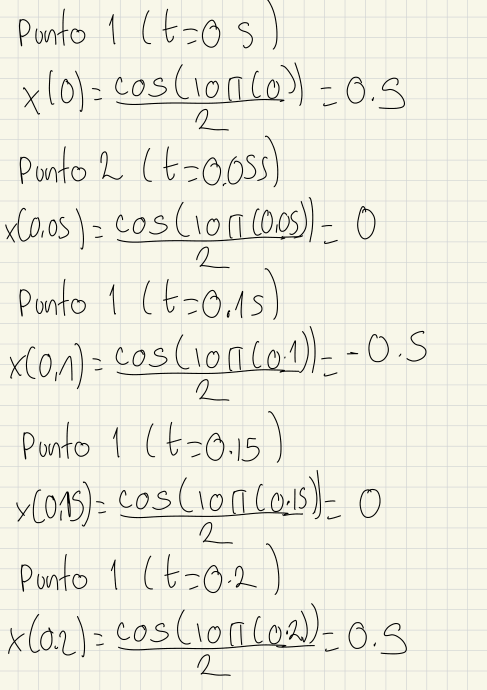

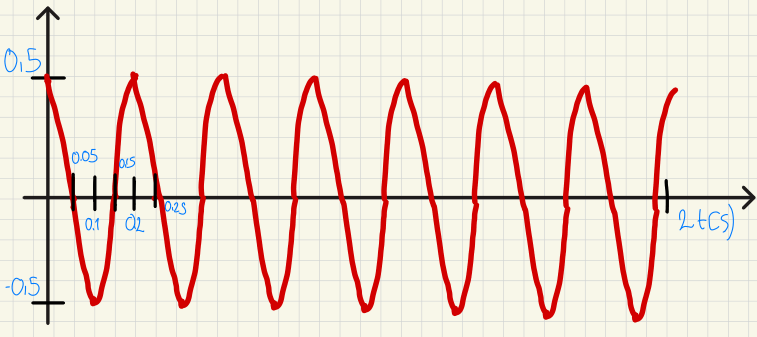

### c) Measure the distance, in samples, between consecutive autocorrelation maxima

In [16]:
rxx_array = np.array(rxx_list)
limite_seguro = len(rxx_array) // 2
rxx_limpio = rxx_array[:limite_seguro]

rxx_redondeado = np.round(rxx_limpio, 4)

# Se consideran picos repetidos
picos_k = np.where((rxx_redondeado[1:-1] >= rxx_redondeado[:-2]) & (rxx_redondeado[1:-1] > rxx_redondeado[2:]))[0] + 1

if len(picos_k) > 1:
    distancias = np.diff(picos_k)
    distancia_muestras = int(np.round(np.mean(distancias)))
    tiempo_tau = distancia_muestras / fs

    print("\n<<<< Resultados c) Distancia entre máximos >>>>\n")
    print(f"Los picos ocurren en k = {picos_k}")
    print(f"Distancias detectadas: {distancias}\n")
    print(f"--> La función alcanza su pico cada: {tiempo_tau}[s]")
    print(f"--> Distancia en muestras: {distancia_muestras} muestras")
else:
    print("\n[!] Advertencia: No se encontraron suficientes picos.")
    print(f"Picos encontrados en k = {picos_k}")
    print("Revisa que tu variable 'x' contiene la onda senoidal correcta.")


<<<< Resultados c) Distancia entre máximos >>>>

Los picos ocurren en k = [20 40 60 80]
Distancias detectadas: [20 20 20]

--> La función alcanza su pico cada: 0.2[s]
--> Distancia en muestras: 20 muestras


*Resultados obtenidos a mano*



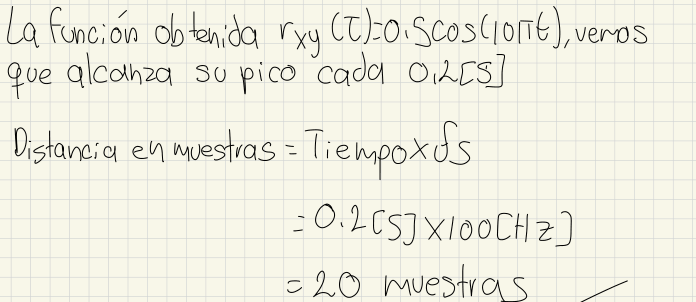

### d) Convert the distance into seconds

In [17]:
print(f"-> Distancia en segundos: {distancia_muestras/100}[s]")

-> Distancia en segundos: 0.2[s]


*Resultados obtenidos a mano*

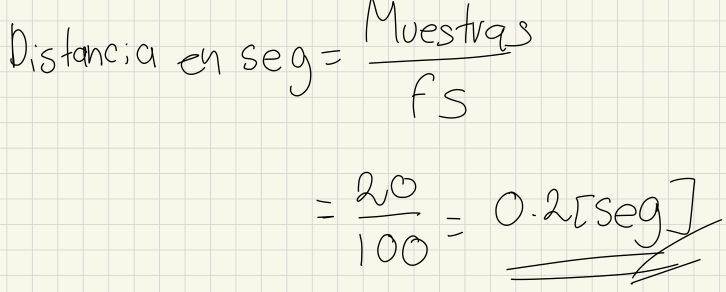

### e) What relationship do you observe between this value and the frequency of the original signal?

El valor máximo de 0.2[s] que se obtiene entree dos máximos consecutivos de la autocorrelación representa el periodo de la señal, es decirm el tiempo que tarda la señal en repetir un ciclo.

Como la frecuencia de la señal original es de 5[Hz], significa que la señal que realiza 5 ciclos cada segundo

$$\boxed{T = \frac{1}{f} = \frac{1}{5} = 0.2 [s]}$$

Esto coincide con los 0.2[s] que observamos en la autocorrelación. Por lo tanto podemos decir la autocorrelación permite identificar el periodo de una señal periódica, ya qe sus máximos aparecen seprados aproximadamente por el mismo tiempo que tarda la señal original en repetirse, es decir la frecuencia y el periodo están directamente relacionados. Si connocemos uno, podemos obtener el otro.

# Excercise 5: Comparing signals with different frequencies
Generate
$$x(t) = sin (2\pi \cdot 5t)$$
$$r_1 (t) = sin(2 \pi \cdot 5t), \quad r_2(t) = sin(2 \pi \cdot 8t)$$

### a) Plot all three signals

/tmp/ipykernel_69567/838027646.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_69567/838027646.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_69567/838027646.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


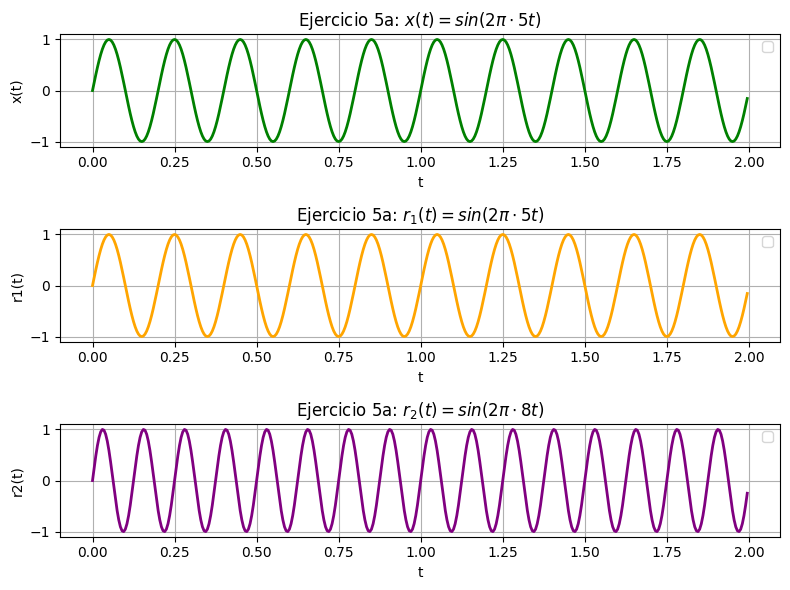

In [18]:
# Definimos los vectores de tiempo 't'
s_max = 2      # Segundos
fs = 200       # Hz (dictado por la onda de 8Hz)

# 2. Vector de tiempo único para todas las señales
t = np.arange(0, s_max, 1/fs)

# 3. Definición de las señales
x  = np.sin(2 * np.pi * 5 * t)
r1 = np.sin(2 * np.pi * 5 * t)
r2 = np.sin(2 * np.pi * 8 * t)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 6))

ax1.plot(t, x, color='green', linewidth=2)
ax1.set_title(r"Ejercicio 5a: $x(t) = sin(2 \pi \cdot 5t)$")
ax1.set_xlabel("t")
ax1.set_ylabel("x(t)")
ax1.grid(True)
ax1.legend()

ax2.plot(t, r1, color='orange', linewidth=2)
ax2.set_title(r"Ejercicio 5a: $r_1(t) = sin(2 \pi \cdot 5t)$")
ax2.set_xlabel("t")
ax2.set_ylabel("r1(t)")
ax2.grid(True)
ax2.legend()

ax3.plot(t, r2, color='purple', linewidth=2)
ax3.set_title(r"Ejercicio 5a: $r_2(t) = sin(2 \pi \cdot 8t)$")
ax3.set_xlabel("t")
ax3.set_ylabel("r2(t)")
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()

*Resultados obtenidos a mano*

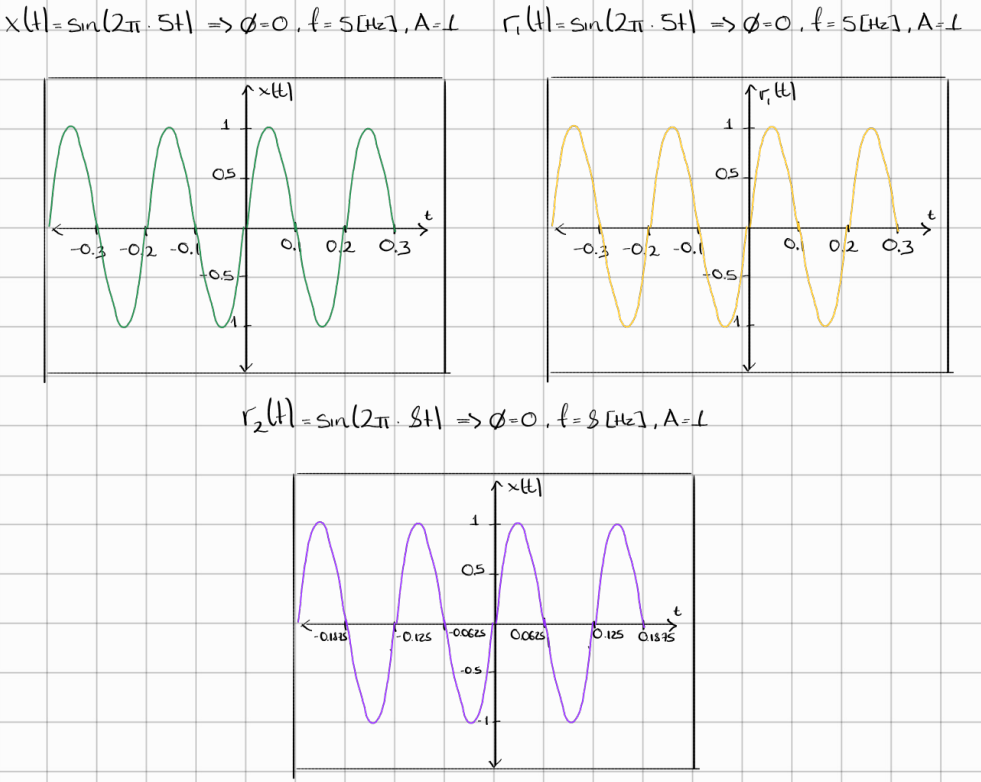

### b) Calculate the cross-correlation between $x(t)$ and each reference

In [19]:
print("<<<< Correlación Cruzada x(t) y r1(t) >>>> \n")

# 3. Llamada directa a la función (Devuelve lags y resultados completos)
lags_k, X_R1 = correlacion_cruzada_continuo(x, r1)

# --- INICIO DEL RECORTE DE VENTANA ---
# Calculamos el 25% de la longitud total para descartar los extremos (colas)
recorte = len(lags_k) // 4

# Sobrescribimos o creamos variables nuevas conservando solo el 50% central
lags_utiles_r1 = lags_k[recorte : -recorte]
X_R1_util = X_R1[recorte : -recorte]
# --- FIN DEL RECORTE ---

# Convertir los retardos k (muestras) a tiempo tau (segundos) usando el arreglo limpio
tau_util_r1 = lags_utiles_r1 / fs

# Mostrar 1 de Cada 25 Valores
NUM_VALORES = 25

# Imprimir los resultados asegurándote de usar las variables recortadas (_util)
for k, t_val, r_val in zip(lags_utiles_r1[::NUM_VALORES], tau_util_r1[::NUM_VALORES], X_R1_util[::NUM_VALORES]):
    print(f"lag = {k:4d} | tau = {t_val:5.2f}s  -->  R_xr1 = {r_val:.4f}")

<<<< Correlación Cruzada x(t) y r1(t) >>>> 

lag = -199 | tau = -0.99s  -->  R_xr1 = 0.4938
lag = -174 | tau = -0.87s  -->  R_xr1 = -0.2838
lag = -149 | tau = -0.74s  -->  R_xr1 = -0.0910
lag = -124 | tau = -0.62s  -->  R_xr1 = 0.4127
lag =  -99 | tau = -0.49s  -->  R_xr1 = -0.4938
lag =  -74 | tau = -0.37s  -->  R_xr1 = 0.2869
lag =  -49 | tau = -0.24s  -->  R_xr1 = 0.0873
lag =  -24 | tau = -0.12s  -->  R_xr1 = -0.4105
lag =    1 | tau =  0.01s  -->  R_xr1 = 0.4963
lag =   26 | tau =  0.13s  -->  R_xr1 = -0.3015
lag =   51 | tau =  0.26s  -->  R_xr1 = -0.0695
lag =   76 | tau =  0.38s  -->  R_xr1 = 0.4000
lag =  101 | tau =  0.51s  -->  R_xr1 = -0.4972
lag =  126 | tau =  0.63s  -->  R_xr1 = 0.3043
lag =  151 | tau =  0.76s  -->  R_xr1 = 0.0660
lag =  176 | tau =  0.88s  -->  R_xr1 = -0.3980


*Resultados obtenidos a mano*

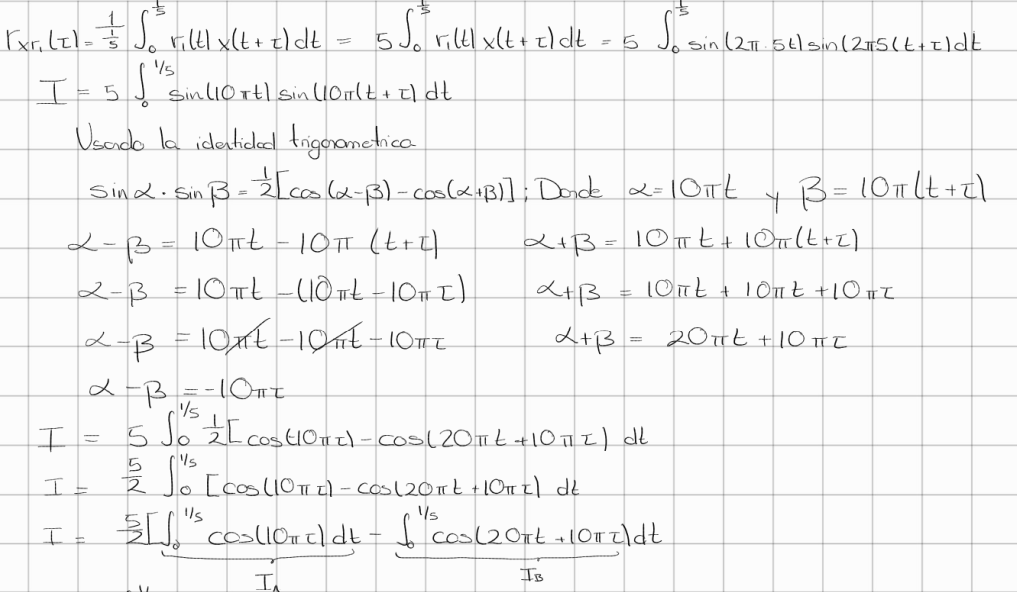

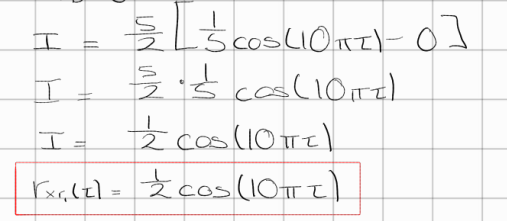

*Para ver el desarrollo completo de estos calculos del inciso b) a mano, se encuentran en el documento PDF*

In [20]:
print("<<<< Correlación Cruzada x(t) y r2(t) >>>> \n")

# 3. Llamada directa a la función (Devuelve lags y resultados completos)
lags_k, X_R2 = correlacion_cruzada_continuo(x, r2)

# --- INICIO DEL RECORTE DE VENTANA ---
# Calculamos el 25% de la longitud total para descartar los extremos (colas)
recorte = len(lags_k) // 4

# Sobrescribimos o creamos variables nuevas conservando solo el 50% central
lags_utiles_r2 = lags_k[recorte : -recorte]
X_R2_util = X_R2[recorte : -recorte]
# --- FIN DEL RECORTE ---

# Convertir los retardos k (muestras) a tiempo tau (segundos) usando el arreglo limpio
tau_util_r2 = lags_utiles_r2 / fs

# Mostrar 1 de Cada 25 Valores
NUM_VALORES = 25

# Imprimir los resultados asegurándote de usar las variables recortadas (_util)
for k, t_val, r_val in zip(lags_utiles_r2[::NUM_VALORES], tau_util_r2[::NUM_VALORES], X_R2_util[::NUM_VALORES]):
    print(f"lag = {k:4d} | tau = {t_val:5.2f}s  -->  R_xr1 = {r_val:.4f}")

<<<< Correlación Cruzada x(t) y r2(t) >>>> 

lag = -199 | tau = -0.99s  -->  R_xr1 = 0.0000
lag = -174 | tau = -0.87s  -->  R_xr1 = 0.0279
lag = -149 | tau = -0.74s  -->  R_xr1 = -0.0216
lag = -124 | tau = -0.62s  -->  R_xr1 = 0.0176
lag =  -99 | tau = -0.49s  -->  R_xr1 = 0.0068
lag =  -74 | tau = -0.37s  -->  R_xr1 = -0.0131
lag =  -49 | tau = -0.24s  -->  R_xr1 = 0.0213
lag =  -24 | tau = -0.12s  -->  R_xr1 = -0.0075
lag =    1 | tau =  0.01s  -->  R_xr1 = 0.0000
lag =   26 | tau =  0.13s  -->  R_xr1 = -0.0168
lag =   51 | tau =  0.26s  -->  R_xr1 = 0.0155
lag =   76 | tau =  0.38s  -->  R_xr1 = -0.0150
lag =  101 | tau =  0.51s  -->  R_xr1 = -0.0068
lag =  126 | tau =  0.63s  -->  R_xr1 = 0.0156
lag =  151 | tau =  0.76s  -->  R_xr1 = -0.0300
lag =  176 | tau =  0.88s  -->  R_xr1 = 0.0126


*Resultados obtenidos a mano*


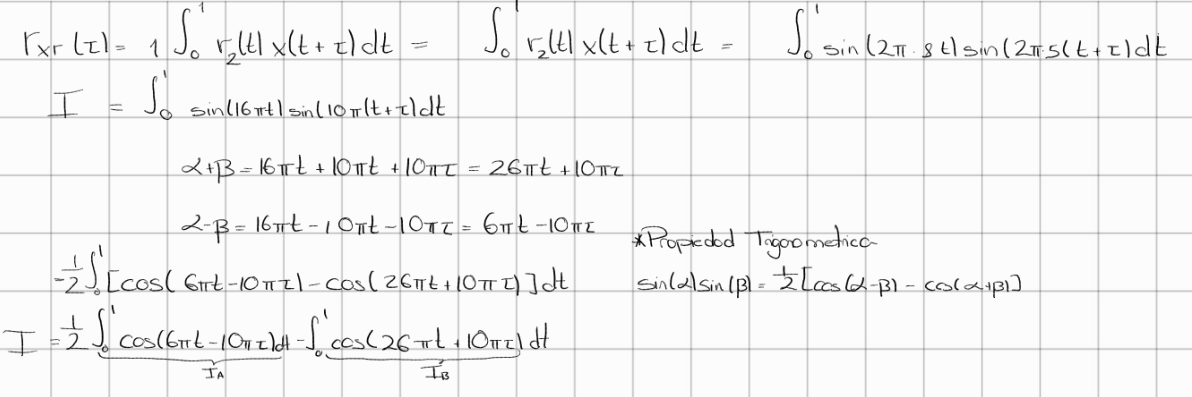

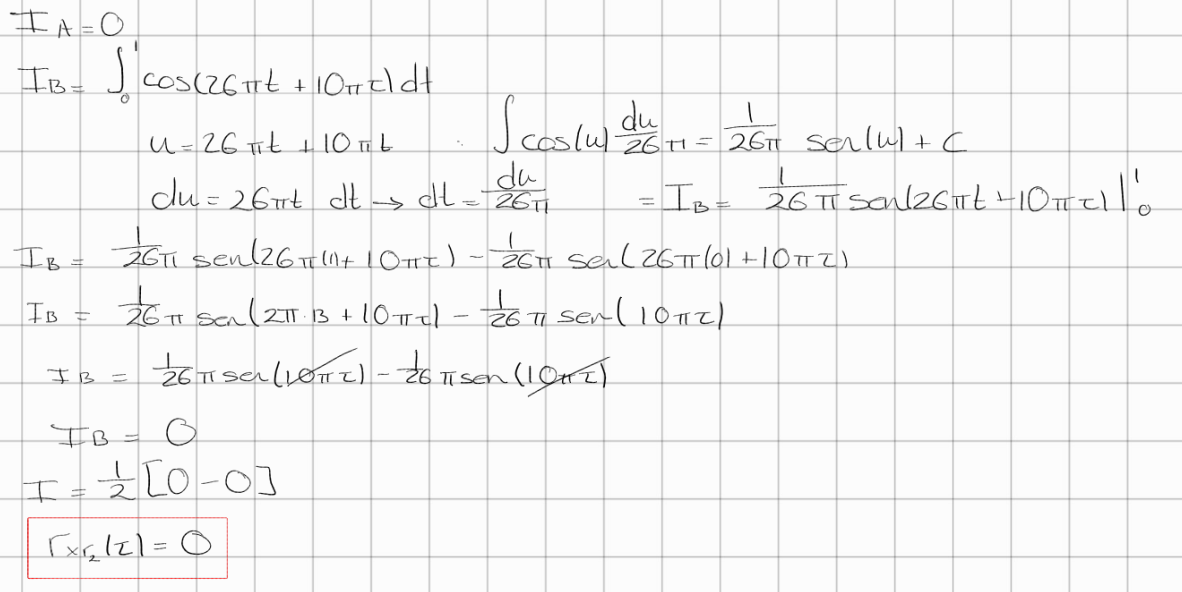

*Para ver el desarrollo completo de estos calculos del inciso b) a mano, se encuentran en el documento PDF*

### c) Compare the maximum absolite correlation obtained in each case

In [21]:
indice_max = np.argmax(np.abs(X_R1_util))

max_rx1 = X_R1_util[indice_max]
max_lag = lags_utiles_r1[indice_max]

print(f"[(R_xr1)] Valor Máximo Absoluto de Correlación: tau = {max_lag/fs} --> R_xr1[{max_lag/fs}] = {abs(max_rx1):.4f}")

[(R_xr1)] Valor Máximo Absoluto de Correlación: tau = -0.9 --> R_xr1[-0.9] = 0.5023


In [22]:
indice_max = np.argmax(np.abs(X_R2_util))

max_rx2 = X_R2_util[indice_max]
max_lag = lags_utiles_r2[indice_max]

print(f"[(R_xr2)] Valor Máximo Absoluto de Correlación: tau = {max_lag/fs} --> R_xr2[{max_lag/fs}] = {abs(max_rx2):.4f}")

[(R_xr2)] Valor Máximo Absoluto de Correlación: tau = 0.845 --> R_xr2[0.845] = 0.0457


*Resultados obtenidos a mano*


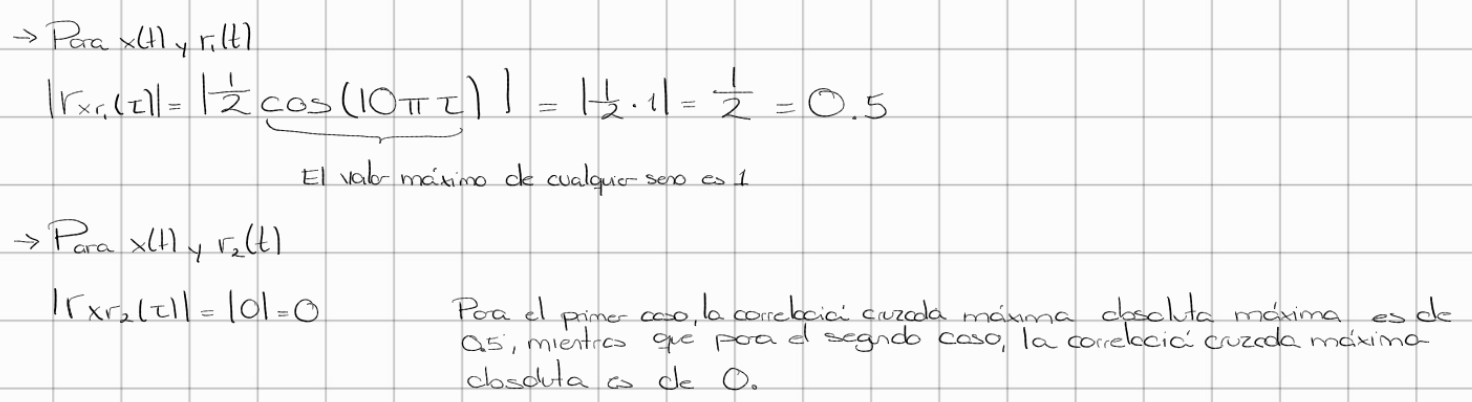

### d) Which reference provides the strongest response? Explain why

El primer caso $x(t)$ y $r_1(t)$ proporciona la respuesta más fuerte debido a que su correlación máxima absoluta es de $0.5$, mientras que para el segundo caso $x(t)$ y $r_2(t)$ es de cero, para el segundo caso la frecuencia de $r_2(t)$ es distinta de $x(t)$, por lo que al integrar se obtiene un valor de cero indicando que son funciones ortogonales, de forma que las señales otrogonales no estan correlacionadas. Como $x(t)$ y $r_1(t)$ no son funciones ortogonales se tiene una alta correlación.

Es importante considerar que no se esta empleando una normalización, el valor de la correlación máximo absoluto representa la potencia entre ambas señales cuando estan perfectamente alineadas, dodne la potencia media media es:
$$P = \frac{A^2}{2}$$

# Excercise 6: Finding a hidden frequency

The observed signal is:
$$x(t) = 2 sin (2 \pi \cdot 7)$$
Asume its frequency is one of \{3,5,7,9,11\} Hz. For every candidate frequency $f$, generate
$$r_f(t) = sin (2 \pi f t)$$

### a) Compute the correlation of x(t) with each reference signal

In [23]:
# Definimos los vectores de tiempo 't'
s_max = 2      # Segundos
fs = 250       # Hz (dictado por la onda de 8Hz)

# 2. Vector de tiempo único para todas las señales
t = np.arange(0, s_max, 1/fs)

# 3. Definición de las señales
x  = 2 * np.sin(2 * np.pi * 7 * t)
rf3 = np.sin(2 * np.pi * 3 * t)
rf5 = np.sin(2 * np.pi * 5 * t)
rf7 = np.sin(2 * np.pi * 7 * t)
rf9 = np.sin(2 * np.pi * 9 * t)
rf11 = np.sin(2 * np.pi * 11 * t)

In [24]:
print("<<<< Correlación Cruzada x(t) y r_f3(t) >>>> \n")

# Calculo de Correlación Cruzada
lags_k, X_F3 = correlacion_cruzada_continuo(x, rf3)

# Definiendo la ventana
recorte = len(lags_k) // 4
lags_utiles_f3 = lags_k[recorte : -recorte]
X_F3_util = X_F3[recorte : -recorte]

tau_util_f3 = lags_utiles_f3 / fs

# Mostrar 1 de Cada 25 Valores
NUM_VALORES = 25

for k, t_val, r_val in zip(lags_utiles_f3[::NUM_VALORES], tau_util_f3[::NUM_VALORES], X_F3_util[::NUM_VALORES]):
    print(f"lag = {k:4d} | tau = {t_val:5.2f}s  -->  R_xr1 = {r_val:.4f}")

<<<< Correlación Cruzada x(t) y r_f3(t) >>>> 

lag = -249 | tau = -1.00s  -->  R_xr1 = 0.0000
lag = -224 | tau = -0.90s  -->  R_xr1 = -0.0683
lag = -199 | tau = -0.80s  -->  R_xr1 = 0.0387
lag = -174 | tau = -0.70s  -->  R_xr1 = 0.0357
lag = -149 | tau = -0.60s  -->  R_xr1 = -0.0537
lag = -124 | tau = -0.50s  -->  R_xr1 = 0.0000
lag =  -99 | tau = -0.40s  -->  R_xr1 = 0.0469
lag =  -74 | tau = -0.30s  -->  R_xr1 = -0.0273
lag =  -49 | tau = -0.20s  -->  R_xr1 = -0.0258
lag =  -24 | tau = -0.10s  -->  R_xr1 = 0.0395
lag =    1 | tau =  0.00s  -->  R_xr1 = -0.0000
lag =   26 | tau =  0.10s  -->  R_xr1 = 0.0397
lag =   51 | tau =  0.20s  -->  R_xr1 = -0.0259
lag =   76 | tau =  0.30s  -->  R_xr1 = -0.0274
lag =  101 | tau =  0.40s  -->  R_xr1 = 0.0472
lag =  126 | tau =  0.50s  -->  R_xr1 = 0.0000
lag =  151 | tau =  0.60s  -->  R_xr1 = -0.0540
lag =  176 | tau =  0.70s  -->  R_xr1 = 0.0359
lag =  201 | tau =  0.80s  -->  R_xr1 = 0.0389
lag =  226 | tau =  0.90s  -->  R_xr1 = -0.0688


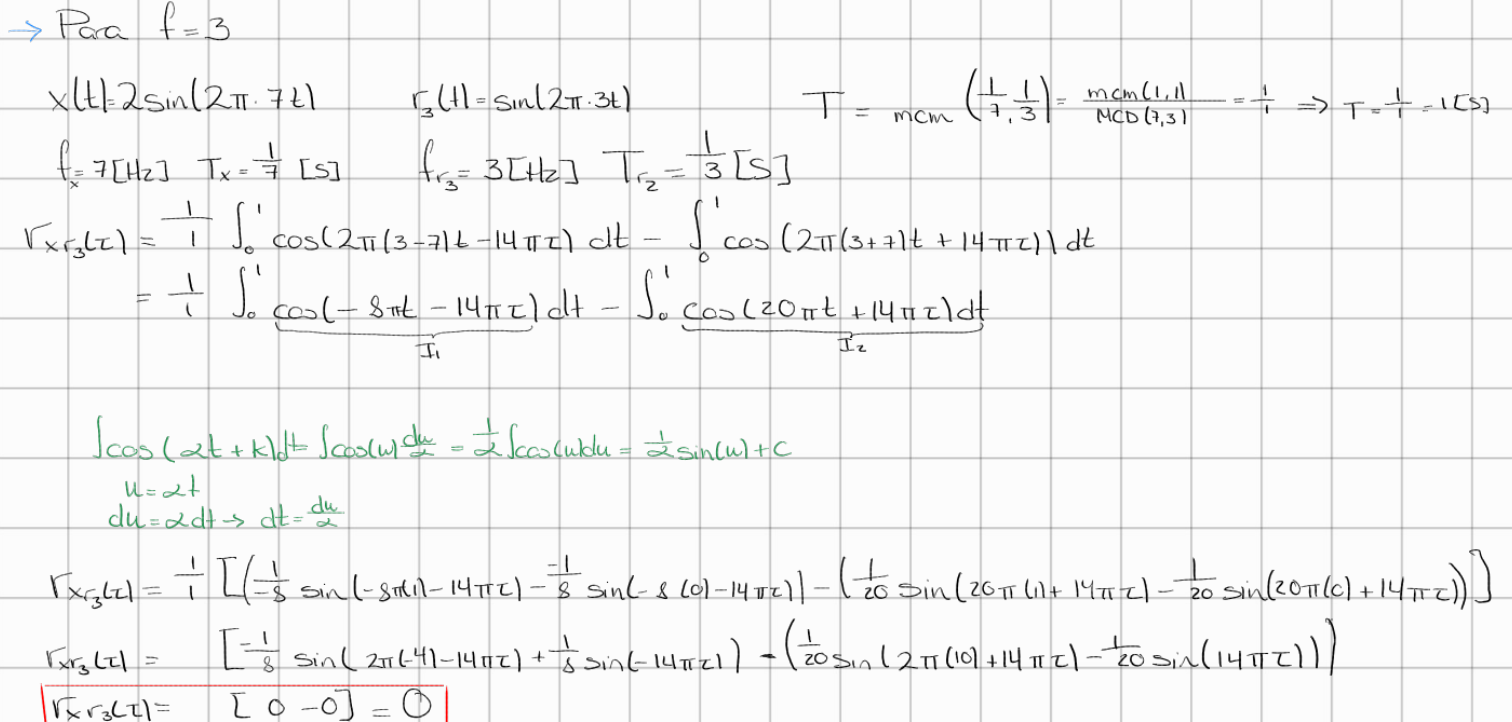

In [25]:
print("<<<< Correlación Cruzada x(t) y r_f5(t) >>>> \n")

# Calculo de Correlación Cruzada
lags_k, X_F5 = correlacion_cruzada_continuo(x, rf5)

# Definiendo la ventana
recorte = len(lags_k) // 4
lags_utiles_f5 = lags_k[recorte : -recorte]
X_F5_util = X_F5[recorte : -recorte]

tau_util_f5 = lags_utiles_f5 / fs

# Mostrar 1 de Cada 25 Valores
NUM_VALORES = 25

for k, t_val, r_val in zip(lags_utiles_f5[::NUM_VALORES], tau_util_f5[::NUM_VALORES], X_F5_util[::NUM_VALORES]):
    print(f"lag = {k:4d} | tau = {t_val:5.2f}s  -->  R_xr1 = {r_val:.4f}")

<<<< Correlación Cruzada x(t) y r_f5(t) >>>> 

lag = -249 | tau = -1.00s  -->  R_xr1 = -0.0000
lag = -224 | tau = -0.90s  -->  R_xr1 = -0.0492
lag = -199 | tau = -0.80s  -->  R_xr1 = 0.0145
lag = -174 | tau = -0.70s  -->  R_xr1 = 0.0457
lag = -149 | tau = -0.60s  -->  R_xr1 = -0.0501
lag = -124 | tau = -0.50s  -->  R_xr1 = 0.0000
lag =  -99 | tau = -0.40s  -->  R_xr1 = 0.0338
lag =  -74 | tau = -0.30s  -->  R_xr1 = -0.0102
lag =  -49 | tau = -0.20s  -->  R_xr1 = -0.0330
lag =  -24 | tau = -0.10s  -->  R_xr1 = 0.0369
lag =    1 | tau =  0.00s  -->  R_xr1 = -0.0000
lag =   26 | tau =  0.10s  -->  R_xr1 = 0.0286
lag =   51 | tau =  0.20s  -->  R_xr1 = -0.0097
lag =   76 | tau =  0.30s  -->  R_xr1 = -0.0351
lag =  101 | tau =  0.40s  -->  R_xr1 = 0.0441
lag =  126 | tau =  0.50s  -->  R_xr1 = 0.0000
lag =  151 | tau =  0.60s  -->  R_xr1 = -0.0389
lag =  176 | tau =  0.70s  -->  R_xr1 = 0.0135
lag =  201 | tau =  0.80s  -->  R_xr1 = 0.0499
lag =  226 | tau =  0.90s  -->  R_xr1 = -0.0643


*Resultados obtenidos a mano*


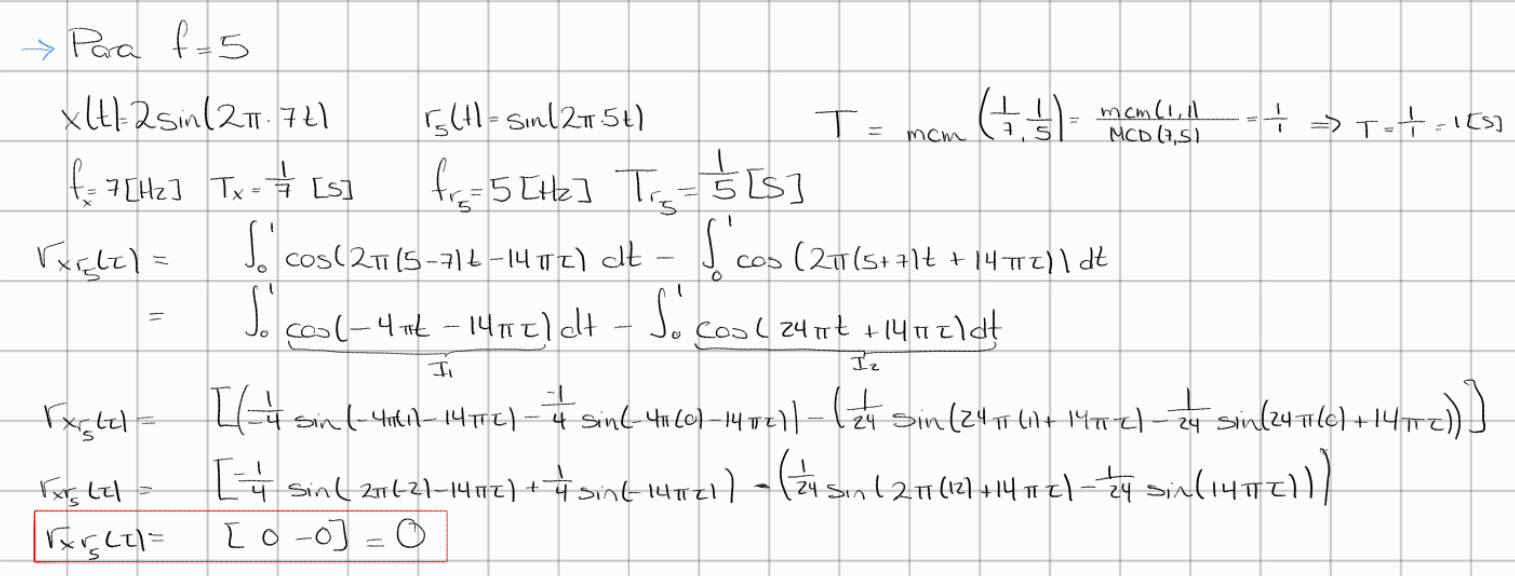

In [26]:
print("<<<< Correlación Cruzada x(t) y r_f7(t) >>>> \n")

# Calculo de Correlación Cruzada
lags_k, X_F7 = correlacion_cruzada_continuo(x, rf7)

# Definiendo la ventana
recorte = len(lags_k) // 4
lags_utiles_f7 = lags_k[recorte : -recorte]
X_F7_util = X_F7[recorte : -recorte]

tau_util_f7 = lags_utiles_f7 / fs

# Mostrar 1 de Cada 25 Valores
NUM_VALORES = 25

for k, t_val, r_val in zip(lags_utiles_f7[::NUM_VALORES], tau_util_f7[::NUM_VALORES], X_F7_util[::NUM_VALORES]):
    print(f"lag = {k:4d} | tau = {t_val:5.2f}s  -->  R_xr1 = {r_val:.4f}")

<<<< Correlación Cruzada x(t) y r_f7(t) >>>> 

lag = -249 | tau = -1.00s  -->  R_xr1 = 0.9846
lag = -224 | tau = -0.90s  -->  R_xr1 = -0.1180
lag = -199 | tau = -0.80s  -->  R_xr1 = -0.9106
lag = -174 | tau = -0.70s  -->  R_xr1 = 0.6833
lag = -149 | tau = -0.60s  -->  R_xr1 = 0.4862
lag = -124 | tau = -0.50s  -->  R_xr1 = -0.9846
lag =  -99 | tau = -0.40s  -->  R_xr1 = 0.1242
lag =  -74 | tau = -0.30s  -->  R_xr1 = 0.9073
lag =  -49 | tau = -0.20s  -->  R_xr1 = -0.6862
lag =  -24 | tau = -0.10s  -->  R_xr1 = -0.4821
lag =    1 | tau =  0.00s  -->  R_xr1 = 0.9885
lag =   26 | tau =  0.10s  -->  R_xr1 = -0.1499
lag =   51 | tau =  0.20s  -->  R_xr1 = -0.8959
lag =   76 | tau =  0.30s  -->  R_xr1 = 0.7049
lag =  101 | tau =  0.40s  -->  R_xr1 = 0.4594
lag =  126 | tau =  0.50s  -->  R_xr1 = -0.9898
lag =  151 | tau =  0.60s  -->  R_xr1 = 0.1542
lag =  176 | tau =  0.70s  -->  R_xr1 = 0.8946
lag =  201 | tau =  0.80s  -->  R_xr1 = -0.7096
lag =  226 | tau =  0.90s  -->  R_xr1 = -0.4542


*Resultados obtenidos a mano*

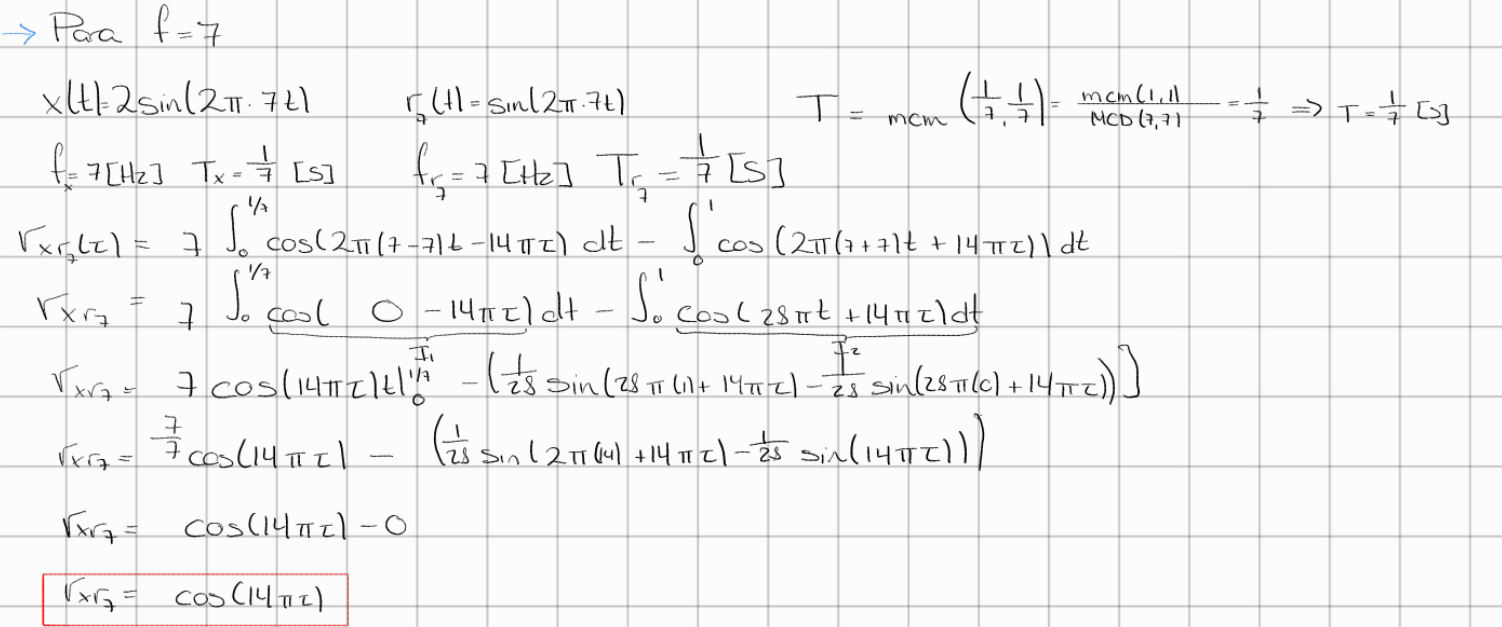

In [27]:
print("<<<< Correlación Cruzada x(t) y r_f9(t) >>>> \n")

# Calculo de Correlación Cruzada
lags_k, X_F9 = correlacion_cruzada_continuo(x, rf9)

# Definiendo la ventana
recorte = len(lags_k) // 4
lags_utiles_f9 = lags_k[recorte : -recorte]
X_F9_util = X_F9[recorte : -recorte]

tau_util_f9 = lags_utiles_f9 / fs

# Mostrar 1 de Cada 25 Valores
NUM_VALORES = 25

for k, t_val, r_val in zip(lags_utiles_f9[::NUM_VALORES], tau_util_f9[::NUM_VALORES], X_F9_util[::NUM_VALORES]):
    print(f"lag = {k:4d} | tau = {t_val:5.2f}s  -->  R_xr1 = {r_val:.4f}")

<<<< Correlación Cruzada x(t) y r_f9(t) >>>> 

lag = -249 | tau = -1.00s  -->  R_xr1 = 0.0000
lag = -224 | tau = -0.90s  -->  R_xr1 = 0.0557
lag = -199 | tau = -0.80s  -->  R_xr1 = -0.0824
lag = -174 | tau = -0.70s  -->  R_xr1 = -0.1030
lag = -149 | tau = -0.60s  -->  R_xr1 = 0.0187
lag = -124 | tau = -0.50s  -->  R_xr1 = -0.0000
lag =  -99 | tau = -0.40s  -->  R_xr1 = -0.0383
lag =  -74 | tau = -0.30s  -->  R_xr1 = 0.0582
lag =  -49 | tau = -0.20s  -->  R_xr1 = 0.0744
lag =  -24 | tau = -0.10s  -->  R_xr1 = -0.0138
lag =    1 | tau =  0.00s  -->  R_xr1 = 0.0000
lag =   26 | tau =  0.10s  -->  R_xr1 = -0.0324
lag =   51 | tau =  0.20s  -->  R_xr1 = 0.0552
lag =   76 | tau =  0.30s  -->  R_xr1 = 0.0791
lag =  101 | tau =  0.40s  -->  R_xr1 = -0.0165
lag =  126 | tau =  0.50s  -->  R_xr1 = -0.0000
lag =  151 | tau =  0.60s  -->  R_xr1 = 0.0440
lag =  176 | tau =  0.70s  -->  R_xr1 = -0.0765
lag =  201 | tau =  0.80s  -->  R_xr1 = -0.1123
lag =  226 | tau =  0.90s  -->  R_xr1 = 0.0240


*Resultados obtenidos a mano*


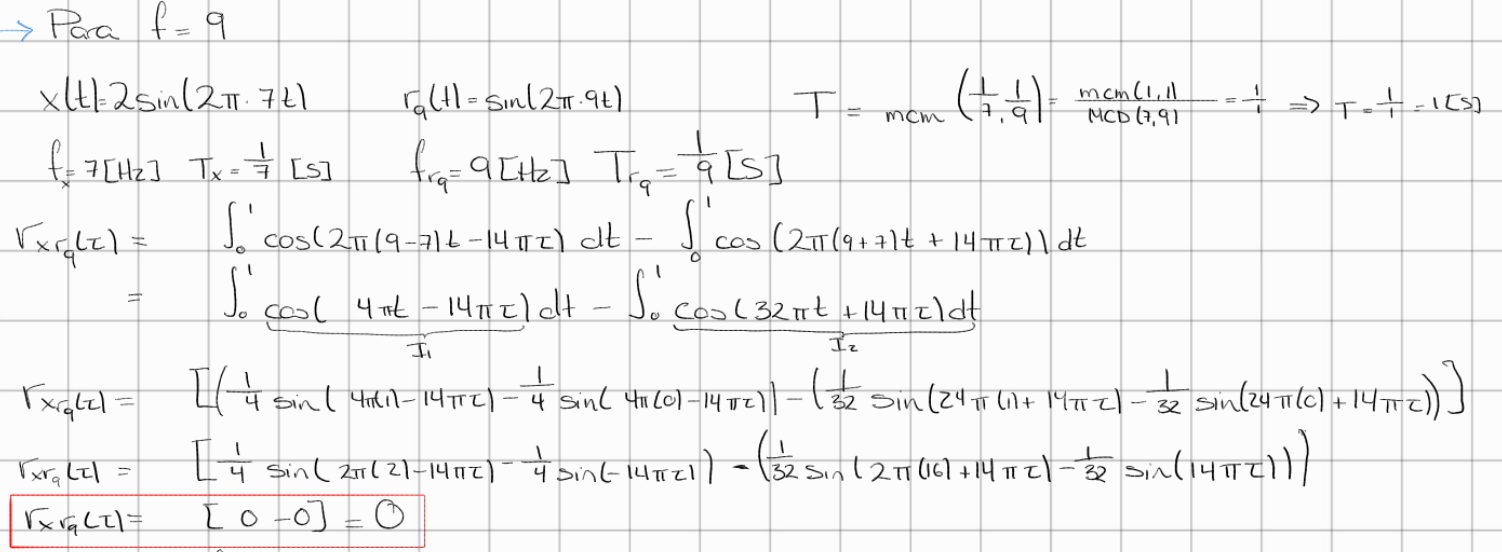

In [28]:
print("<<<< Correlación Cruzada x(t) y r_f11(t) >>>> \n")

# Calculo de Correlación Cruzada
lags_k, X_F11 = correlacion_cruzada_continuo(x, rf11)

# Definiendo la ventana
recorte = len(lags_k) // 4
lags_utiles_f11 = lags_k[recorte : -recorte]
X_F11_util = X_F11[recorte : -recorte]

tau_util_f11 = lags_utiles_f11 / fs

# Mostrar 1 de Cada 25 Valores
NUM_VALORES = 25

for k, t_val, r_val in zip(lags_utiles_f11[::NUM_VALORES], tau_util_f11[::NUM_VALORES], X_F11_util[::NUM_VALORES]):
    print(f"lag = {k:4d} | tau = {t_val:5.2f}s  -->  R_xr1 = {r_val:.4f}")

<<<< Correlación Cruzada x(t) y r_f11(t) >>>> 

lag = -249 | tau = -1.00s  -->  R_xr1 = -0.0000
lag = -224 | tau = -0.90s  -->  R_xr1 = 0.0658
lag = -199 | tau = -0.80s  -->  R_xr1 = 0.0082
lag = -174 | tau = -0.70s  -->  R_xr1 = -0.0070
lag = -149 | tau = -0.60s  -->  R_xr1 = 0.0382
lag = -124 | tau = -0.50s  -->  R_xr1 = 0.0000
lag =  -99 | tau = -0.40s  -->  R_xr1 = -0.0453
lag =  -74 | tau = -0.30s  -->  R_xr1 = -0.0058
lag =  -49 | tau = -0.20s  -->  R_xr1 = 0.0051
lag =  -24 | tau = -0.10s  -->  R_xr1 = -0.0281
lag =    1 | tau =  0.00s  -->  R_xr1 = -0.0000
lag =   26 | tau =  0.10s  -->  R_xr1 = -0.0383
lag =   51 | tau =  0.20s  -->  R_xr1 = -0.0055
lag =   76 | tau =  0.30s  -->  R_xr1 = 0.0054
lag =  101 | tau =  0.40s  -->  R_xr1 = -0.0336
lag =  126 | tau =  0.50s  -->  R_xr1 = -0.0000
lag =  151 | tau =  0.60s  -->  R_xr1 = 0.0520
lag =  176 | tau =  0.70s  -->  R_xr1 = 0.0076
lag =  201 | tau =  0.80s  -->  R_xr1 = -0.0076
lag =  226 | tau =  0.90s  -->  R_xr1 = 0.0489


*Resultados obtenidos a mano*

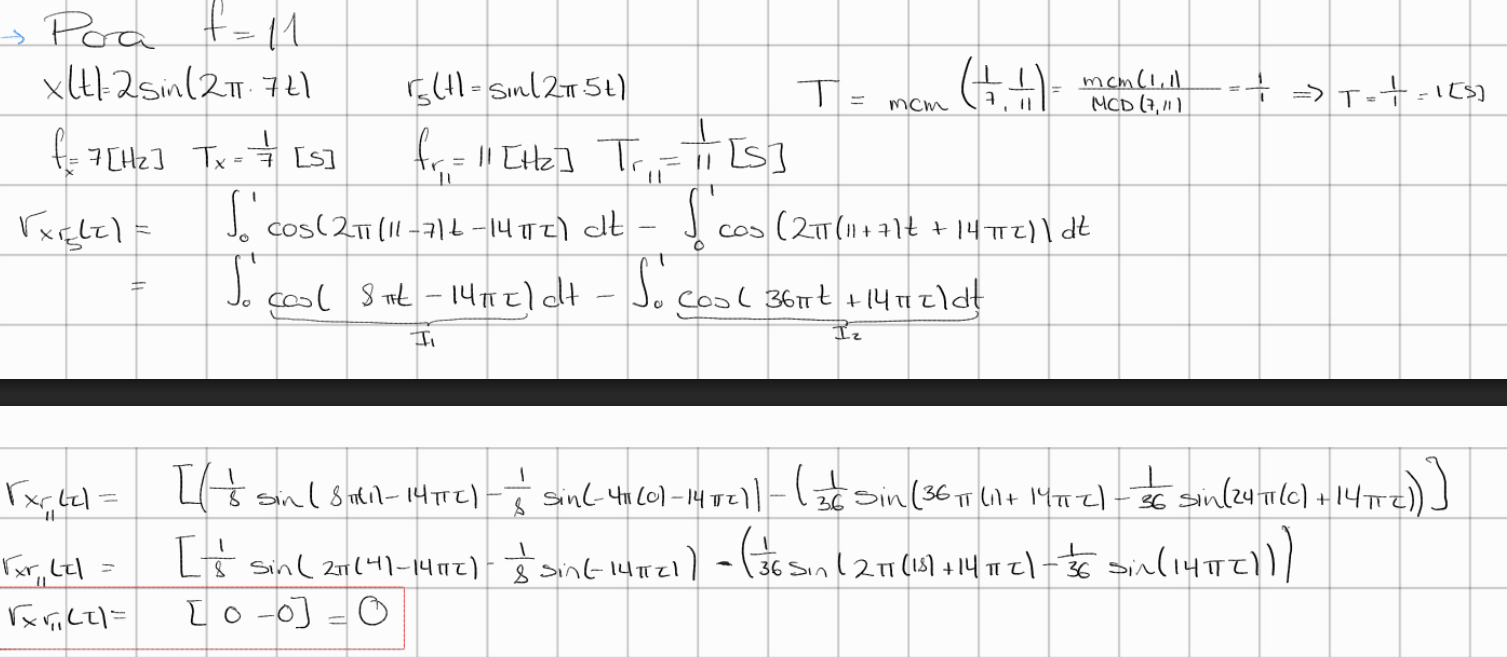

### b) Store the maximum absolute correlation obtained for each frequency

In [29]:
def extraer_maximo_correlacion(corr_util, lags_util, fs, etiqueta):
  indice_max = np.argmax(np.abs(corr_util))
  max_val = corr_util[indice_max]
  max_lag = lags_util[indice_max]
  tau = max_lag / fs

  valor_absoluto = abs(max_val)
  print(f"[(R_x{etiqueta})] Valor Máximo Absoluto de Correlación: tau = {tau} --> R_x{etiqueta}[{tau}] = {valor_absoluto:.4f}")

  return valor_absoluto

datos_correlacion = [
    (X_F3_util, lags_utiles_f3, "f3"),
    (X_F5_util, lags_utiles_f5, "f5"),
    (X_F7_util, lags_utiles_f7, "f7"),
    (X_F9_util, lags_utiles_f9, "f9"),
    (X_F11_util, lags_utiles_f11, "f11")
]

# 2. Ejecutas la función en un ciclo o comprensión de lista
max_corr = []
for corr, lags, nombre in datos_correlacion:
    maximo = extraer_maximo_correlacion(corr, lags, fs, nombre)
    max_corr.append(maximo)


[(R_xf3)] Valor Máximo Absoluto de Correlación: tau = 0.9 --> R_xf3[0.9] = 0.0690
[(R_xf5)] Valor Máximo Absoluto de Correlación: tau = 0.752 --> R_xf5[0.752] = 0.1276
[(R_xf7)] Valor Máximo Absoluto de Correlación: tau = -0.928 --> R_xf7[-0.928] = 1.0029
[(R_xf9)] Valor Máximo Absoluto de Correlación: tau = -0.752 --> R_xf9[-0.752] = 0.1273
[(R_xf11)] Valor Máximo Absoluto de Correlación: tau = -0.888 --> R_xf11[-0.888] = 0.0706


*Resultados obtenidos a mano*

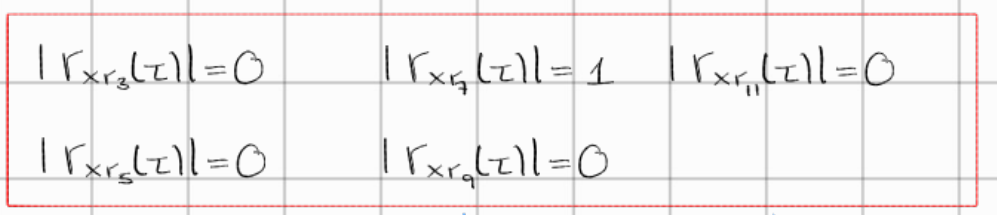

### c) Plot corrrelation magnitude versus candidate frequency

/tmp/ipykernel_69567/3429949319.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


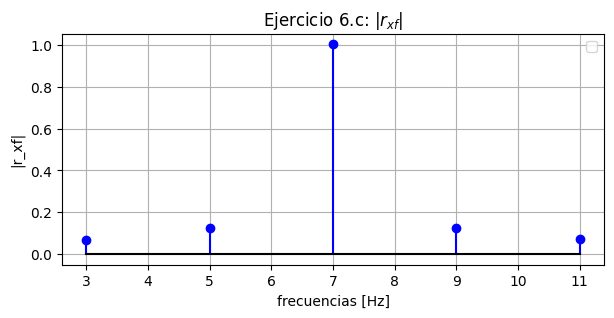

In [30]:
freq = [3,5,7,9,11]

plt.stem(freq, max_corr, linefmt='blue', markerfmt='b', basefmt='black')
plt.title(r"Ejercicio 6.c: $|r_{xf}|$")
plt.xlabel("frecuencias [Hz]")
plt.ylabel("|r_xf|")
plt.grid(True)
plt.legend()
plt.show()

*Resultados obtenidos a mano*


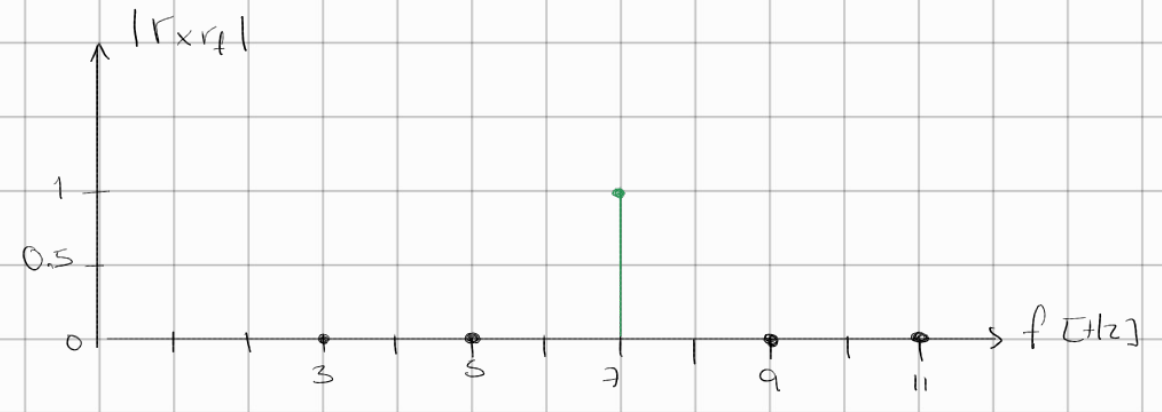

### d) Determine de frequency present in $x(t)$

  Considerando la forma general de una señal sinusoidal:
  $$y(t) = Asin(\omega t +  \phi)$$

  Donde:
  - $A$: Amplitud
  - $\omega = 2 \pi f$: Frecuencia Angular
  - $\phi$: Angulo de Desface

  Considerando la señal $x(t)$
  $$x(t) = 2 sin (2 \pi \cdot 7t) $$

  Se puede identificar que la señal $x(t)$ tiene una amplitud de 2 ($A=2$), no tiene angulo de desface ($\phi = 0$) y su frecuencia angular es:
  $$\omega = 2 \pi \cdot 7 \rightarrow f = 7 [hz]$$

Por lo tanto la frecuencia presente en $x(t)$ es
  $$\boxed{f = 7 [Hz]}$$

# Excercise 7: Detecting two frequencies
Consider
$$x(t) = 2 \sin(2\pi \cdot 5t) + 0.8 \sin(2\pi \cdot 12t)$$
Sample the signal at $f_s = 100\text{ Hz}$ for 2 seconds. Test candidate frequencies $f = \{2, 3, 4, ..., 20\}\text{ Hz}$ using
$$r_f(t) = \sin(2\pi ft)$$

### a) Plot x(t)

/tmp/ipykernel_69567/2002390369.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


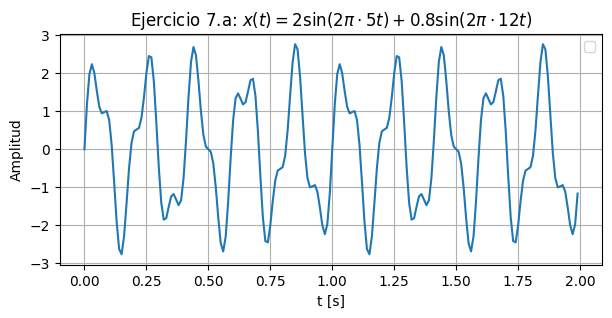

In [31]:
fs = 100
t = np.arange(0, 2, 1/fs)

x = 2 * np.sin(2 * np.pi * 5 * t) + 0.8 * np.sin(2 * np.pi * 12 * t)

plt.plot(t, x)
plt.title(r"Ejercicio 7.a: $x(t) = 2 \sin(2\pi \cdot 5t) + 0.8 \sin(2\pi \cdot 12t)$")
plt.xlabel("t [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()

*Resultados obtenidos manualmente*

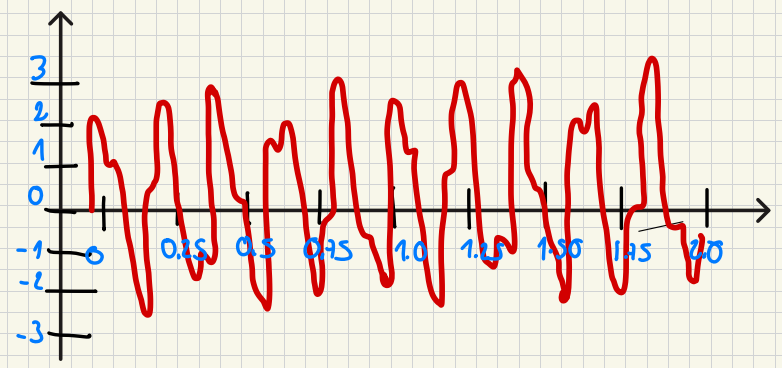

### b) Compute its correlation with every reference sinusoid.

Dos ondas senoidales con frecuencias diferentes son ortogonales cuando completan ciclos enteros. Al multiplicarlas, sus partes positivas y negativas se cancelan, haciendo que la integral sea $0$. Entonces, si probamos con cualquier frecuencia que no sea $5\text{ Hz}$ o $12\text{ Hz}$, el resultado será cero. Solo vamos a calcularlo para $5\text{ Hz}$ y $12\text{ Hz}$.

Usamos la fórmula para correlación no normalizada en el intervalo de 2 segundos:
$$C(f) = \frac{1}{2} \int_{0}^{2} x(t) \cdot r_f(t) dt$$

**Para $f = 5\text{ Hz}$:**
$$C(5) = \frac{1}{2} \int_{0}^{2} [2\sin(10\pi t) + 0.8\sin(24\pi t)] \sin(10\pi t) dt$$
La onda de $12\text{ Hz}$ interactúa con la prueba de $5\text{ Hz}$ y, al ser diferentes, se hace $0$. La onda de $5\text{ Hz}$ interactúa consigo misma formando un seno al cuadrado:
$$C(5) = \frac{1}{2} \int_{0}^{2} 2\sin^2(10\pi t) dt$$
Usando la identidad $\sin^2(\theta) = \frac{1 - \cos(2\theta)}{2}$:
$$C(5) = \frac{1}{2} \int_{0}^{2} 2 \left( \frac{1 - \cos(20\pi t)}{2} \right) dt$$
$$C(5) = \frac{1}{2} \left[ \int_{0}^{2} 1 dt - \int_{0}^{2} \cos(20\pi t) dt \right]$$
Integrando $\cos(at) = \frac{\sin(at)}{a}$:
$$C(5) = \frac{1}{2} \left[ t - \frac{\sin(20\pi t)}{20\pi} \right]_{0}^{2}$$
$$C(5) = \frac{1}{2} \left[ \left(2 - \frac{\sin(40\pi)}{20\pi}\right) - \left(0 - \frac{\sin(0)}{20\pi}\right) \right]$$
$$\boxed{C(5) = \frac{1}{2} [2 - 0] - [0 - 0] = \frac{1}{2}(2) = \mathbf{1}}$$

**Para $f = 12\text{ Hz}$:**
$$C(12) = \frac{1}{2} \int_{0}^{2} [2\sin(10\pi t) + 0.8\sin(24\pi t)] \sin(24\pi t) dt$$
Lo mismo sucede aquí: la onda de $5\text{ Hz}$ se anula por ortogonalidad, dejando solo la interacción de $12\text{ Hz}$:
$$C(12) = \frac{1}{2} \int_{0}^{2} 0.8\sin^2(24\pi t) dt$$
Aplicando la misma identidad trigonométrica:
$$C(12) = \frac{1}{2} \int_{0}^{2} 0.8 \left( \frac{1 - \cos(48\pi t)}{2} \right) dt$$
$$C(12) = 0.2 \left[ \int_{0}^{2} 1 dt - \int_{0}^{2} \cos(48\pi t) dt \right]$$
$$C(12) = 0.2 \left[ t - \frac{\sin(48\pi t)}{48\pi} \right]_{0}^{2}$$
$$C(12) = 0.2 \left[ \left(2 - \frac{\sin(96\pi)}{48\pi}\right) - \left(0 - \frac{\sin(0)}{48\pi}\right) \right]$$
$$\boxed{C(12) = 0.2 [2 - 0] - [0 - 0] = \mathbf{0.4}}$$

*Para ver el desarrollo completo de estos calculos del inciso b) a mano, se encuentran en el documento PDF*


### c) For each frequency, obtain a single measure representing the strength of the correlation.


In [32]:
# Frecuencias candidatas de 2 a 20 Hz
f_candidatas = np.arange(2, 21)
correlaciones = np.zeros(len(f_candidatas))

print("Resultados de la correlación:\n")
for i, f in enumerate(f_candidatas):
    rf = np.sin(2 * np.pi * f * t)

    # Llamamosa la funcion
    corr_val = correlacion_continua_magnitud(x, rf)

    # Redondeammos a un decimal
    correlaciones[i] = np.round(np.abs(corr_val), 1)

    print(f"Frecuencia {f:2d} Hz -> Magnitud: {correlaciones[i]}")

Resultados de la correlación:

Frecuencia  2 Hz -> Magnitud: 0.0
Frecuencia  3 Hz -> Magnitud: 0.0
Frecuencia  4 Hz -> Magnitud: 0.0
Frecuencia  5 Hz -> Magnitud: 1.0
Frecuencia  6 Hz -> Magnitud: 0.0
Frecuencia  7 Hz -> Magnitud: 0.0
Frecuencia  8 Hz -> Magnitud: 0.0
Frecuencia  9 Hz -> Magnitud: 0.0
Frecuencia 10 Hz -> Magnitud: 0.0
Frecuencia 11 Hz -> Magnitud: 0.0
Frecuencia 12 Hz -> Magnitud: 0.4
Frecuencia 13 Hz -> Magnitud: 0.0
Frecuencia 14 Hz -> Magnitud: 0.0
Frecuencia 15 Hz -> Magnitud: 0.0
Frecuencia 16 Hz -> Magnitud: 0.0
Frecuencia 17 Hz -> Magnitud: 0.0
Frecuencia 18 Hz -> Magnitud: 0.0
Frecuencia 19 Hz -> Magnitud: 0.0
Frecuencia 20 Hz -> Magnitud: 0.0


Las medidas de fuerza de correlación son **1** para $5\text{ Hz}$ y **0.4** para $12\text{ Hz}$. Para el resto de las frecuencias candidatas, la fuerza es **0**.

### d) Plot correlation magnitude versus frequency.


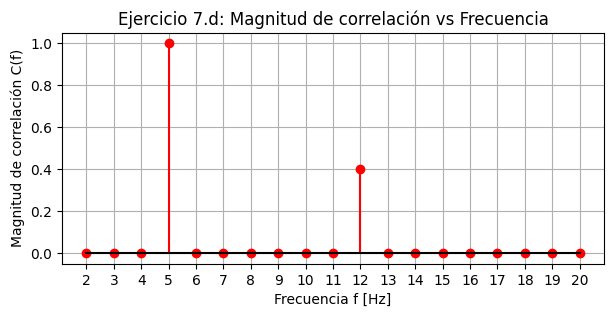

In [33]:
# d) Gráfica de Magnitud vs Frecuencia
plt.stem(f_candidatas, np.abs(correlaciones), linefmt='r-', markerfmt='ro', basefmt='k-')
plt.title("Ejercicio 7.d: Magnitud de correlación vs Frecuencia")
plt.xlabel("Frecuencia f [Hz]")
plt.ylabel("Magnitud de correlación C(f)")
plt.xticks(f_candidatas)
plt.grid(True)
plt.show()

*Resultados obtenidos manualmente*

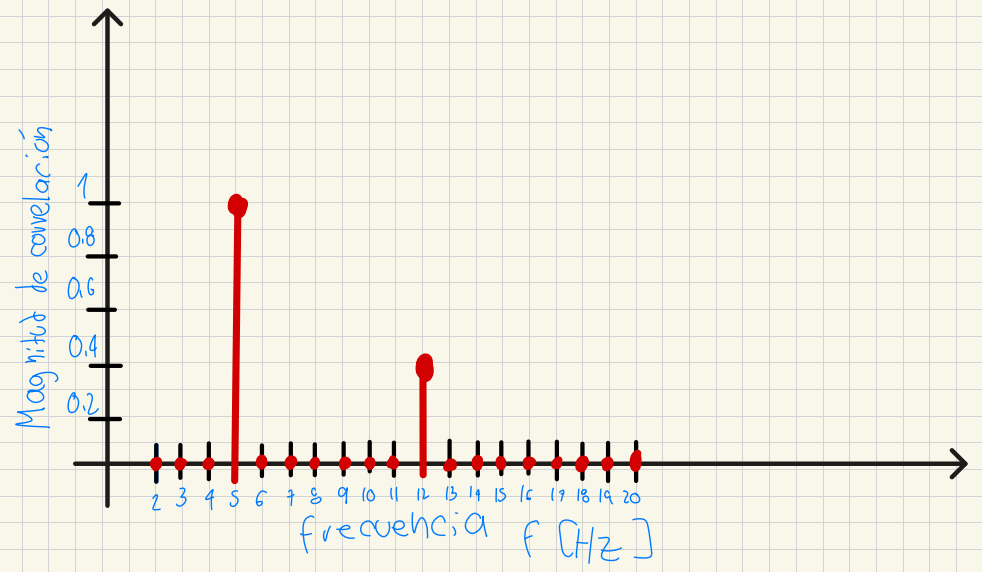

### e) Identify the two dominant frequencies.**


Al observar la gráfica del espectro que se obtuvo en el inciso anterior, podemos ver que es bastante obvio que las únicas frecuencias que reaccionaron a nuestra prueba de correlación y formaron un pico son **5 Hz** y **12 Hz**, siendo estas las frecuencias dominantes. Todas las demás tienen magnitud 0.


### f) Can the relative amplitudes of the two components be inferred from the correlation results? Explain.  

Sí, se pueden inferir las amplitudes relativas de los dos componentes observando los valores de la correlación. La correlación conserva la proporción entre las amplitudes, aunque sus valores se reduzcan a la mitad.

$$\frac{C(5)}{C(12)} = \frac{1}{0.4} = 2.5$$

Esto significa que el componente de 5 Hz es 2.5 veces mayor que el de 12 Hz. Además coincide con las amplitudes originales ($\frac{2}{0.8} = 2.5$). Por lo tanto, los resultados de correlación permiten saber qué componente tiene mayor amplitud y cuál es la relación entre ellos.

# Excercise 8: Phase and sinusoidal detection
Consider two signals with the same frequency but different phase:
$$x_1(t) = \sin(2\pi \cdot 8t)$$
$$x_2(t) = \sin(2\pi \cdot 8t + \pi/3)$$
Initially use the sine reference
$$r_s(t) = \sin(2\pi \cdot 8t)$$

### a) Plot $x_1(t)$, $x_2(t)$, and $r_s(t)$

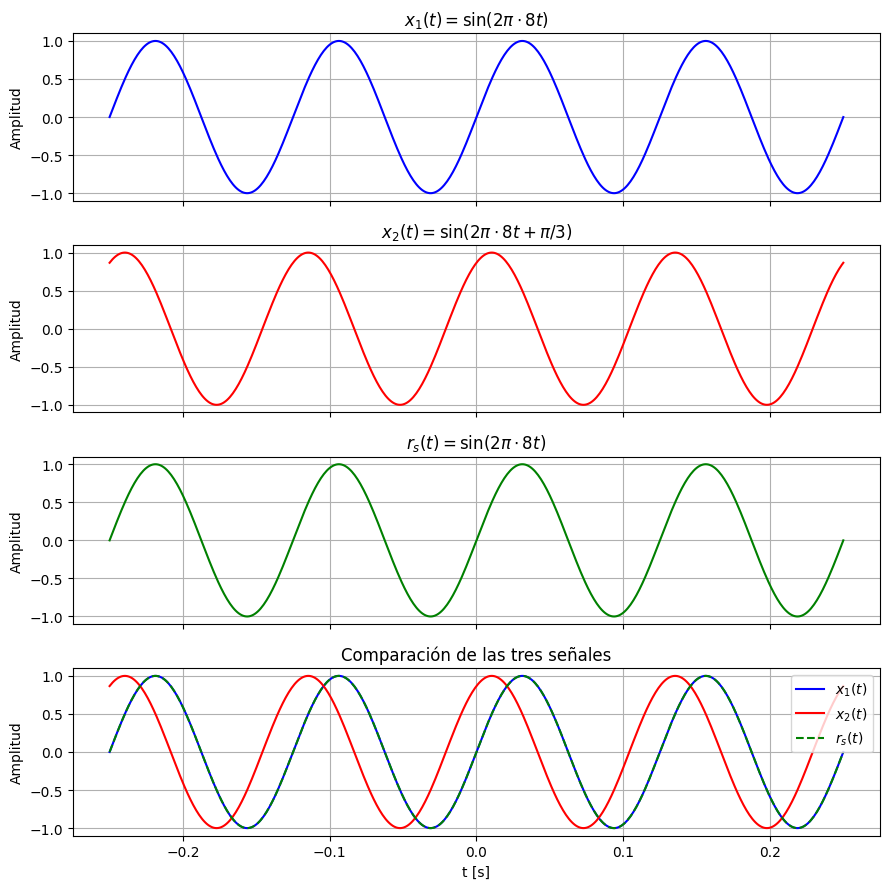

In [34]:
fs_plot = 1000
t_plot = np.arange(-0.25, 0.25 + 1/fs_plot, 1/fs_plot)

x1 = np.sin(2 * np.pi * 8 * t_plot)
x2 = np.sin(2 * np.pi * 8 * t_plot + np.pi/3)
rs = np.sin(2 * np.pi * 8 * t_plot)

fig, axs = plt.subplots(4, 1, figsize=(9, 9), sharex=True)

axs[0].plot(t_plot, x1, 'b-')
axs[0].set_title(r"$x_1(t) = \sin(2\pi \cdot 8t)$")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)

axs[1].plot(t_plot, x2, 'r-')
axs[1].set_title(r"$x_2(t) = \sin(2\pi \cdot 8t + \pi/3)$")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True)

axs[2].plot(t_plot, rs, 'g-')
axs[2].set_title(r"$r_s(t) = \sin(2\pi \cdot 8t)$")
axs[2].set_ylabel("Amplitud")
axs[2].grid(True)

# Gráfica conjunta
axs[3].plot(t_plot, x1, 'b-', label=r"$x_1(t)$")
axs[3].plot(t_plot, x2, 'r-', label=r"$x_2(t)$")
axs[3].plot(t_plot, rs, 'g--', label=r"$r_s(t)$")
axs[3].set_title("Comparación de las tres señales")
axs[3].set_xlabel("t [s]")
axs[3].set_ylabel("Amplitud")
axs[3].legend(loc="upper right")
axs[3].grid(True)

plt.tight_layout()
plt.show()

*Resultados obtenidos manualmente*

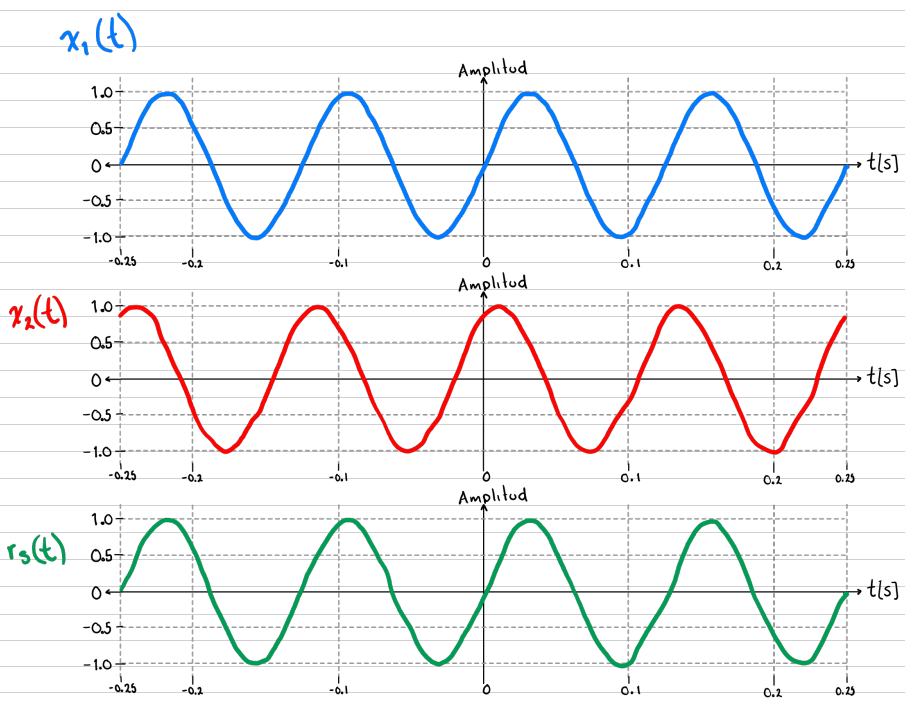

### b) Compute the correlation between $x_1(t)$ and $r_s(t)$.


In [35]:
t_periodo = np.arange(0, 0.125, 1/fs_plot)

x1_p = np.sin(2 * np.pi * 8 * t_periodo)
rs_p = np.sin(2 * np.pi * 8 * t_periodo)

# Correlación x1 con seno
corr_x1_rs = correlacion_continua_magnitud(x1_p, rs_p)

print(f"b) Correlación entre x1(t) y rs(t): {corr_x1_rs:.2f}")

b) Correlación entre x1(t) y rs(t): 0.50


*Resultados obtenidos manualmente*

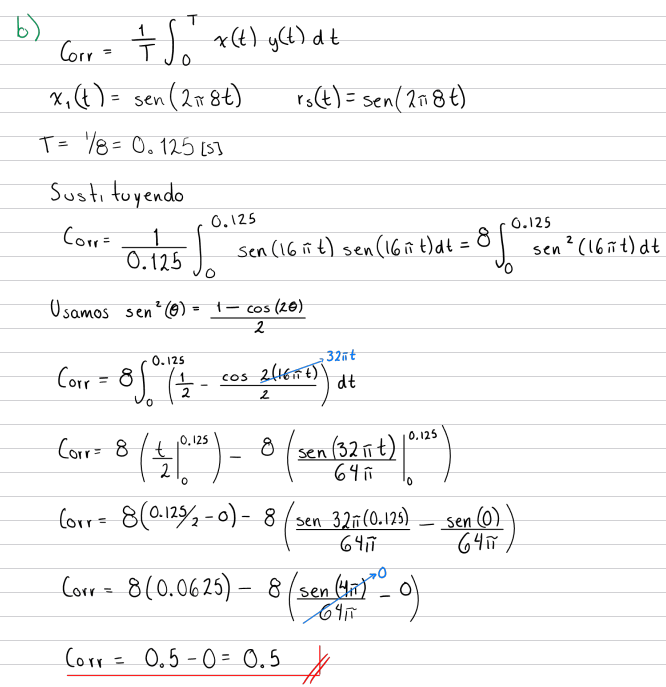

### c) Compute the correlation between $x_2(t)$ and $r_s(t)$.

In [36]:
t_periodo = np.arange(0, 0.125, 1/fs_plot)

x2_p = np.sin(2 * np.pi * 8 * t_periodo + np.pi/3)
rs_p = np.sin(2 * np.pi * 8 * t_periodo)

#Correlación con seno
corr_x2_rs = correlacion_continua_magnitud(x2_p, rs_p)

print(f"c) Correlación entre x2(t) y rs(t): {corr_x2_rs:.2f}")

c) Correlación entre x2(t) y rs(t): 0.25


*Resultados obtenidos manualmente*

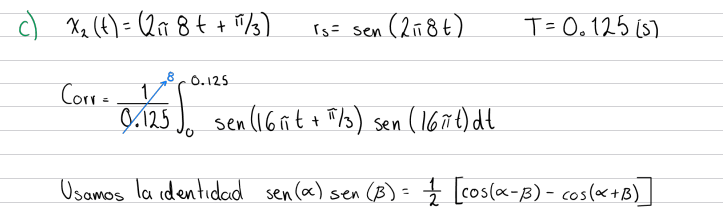

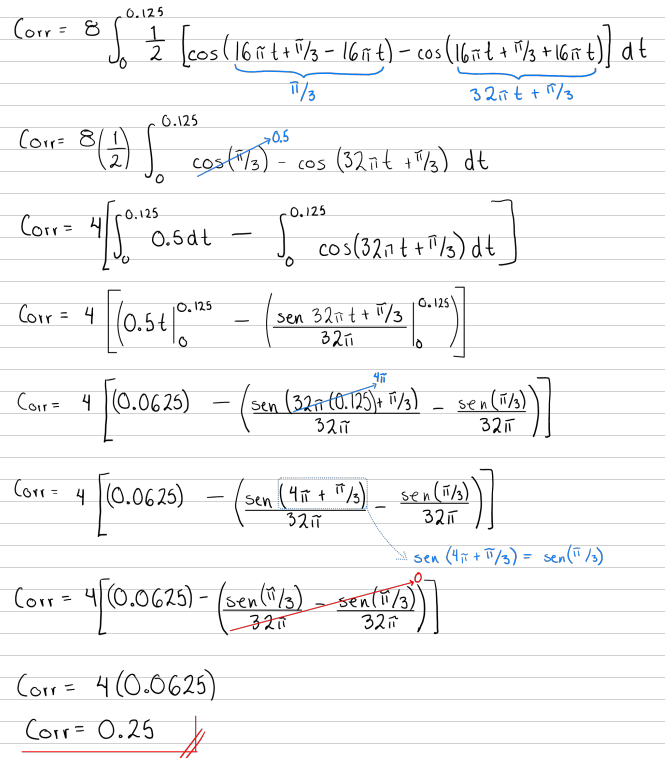

### d) Compare the two results. Both signals have the same frequency. Why are their correlation values different?

La diferencia entre sus valores de correlación ($0.5$ vs $0.25$) ocurre porque se está evaluando el **alineamiento de fase** entre las ondas, no únicamente que tengan la misma frecuencia.

* En el caso de $x_1(t)$ y $r_s(t)$, los ciclos coinciden exactamente. Como los valores positivos se multiplican con positivos y negativos con negativos durante todo el periodo, dan la correlación más alta de $0.5$.
* En el caso de $x_2(t)$ y $r_s(t)$, las señales van desfasadas por $\pi/3$. En algunas fracciones de tiempo una señal es positiva y la otra negativa, y el producto de estas genera áreas negativas en la integral, lo que termina restando en el resultado final y baja la correlación a la mitad, dando un valor de $0.25$.

### e) Now use the cosine reference $r_c(t) = \cos(2\pi \cdot 8t)$ and compute its correlation with $x_1(t)$ and $x_2(t)$.

In [37]:
rc_p = np.cos(2 * np.pi * 8 * t_periodo)

corr_x1_rc = correlacion_continua_magnitud(x1_p, rc_p)
corr_x2_rc = correlacion_continua_magnitud(x2_p, rc_p)

print(f"e) Correlación entre x1(t) y rc(t): {np.round(abs(corr_x1_rc), 1)}")
print(f"e) Correlación entre x2(t) y rc(t): {corr_x2_rc:.3f}")

e) Correlación entre x1(t) y rc(t): 0.0
e) Correlación entre x2(t) y rc(t): 0.433


*Resultados obtenidos manualmente*

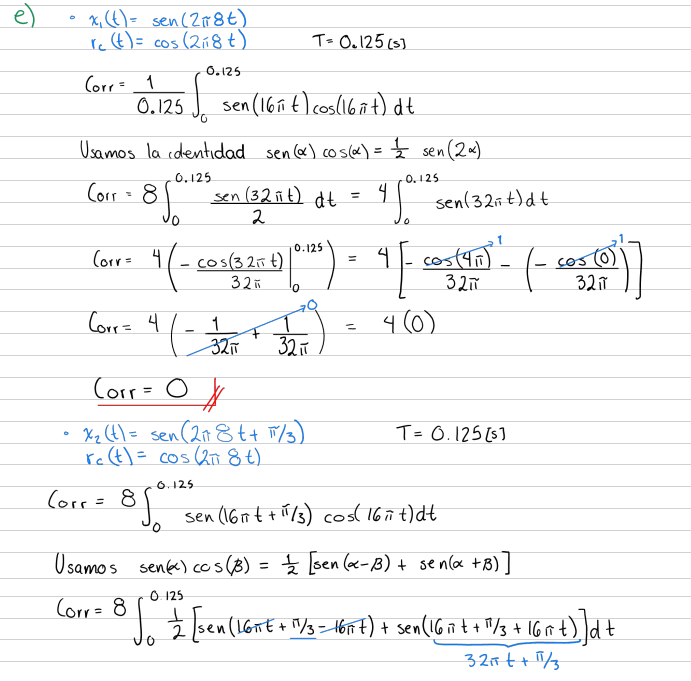

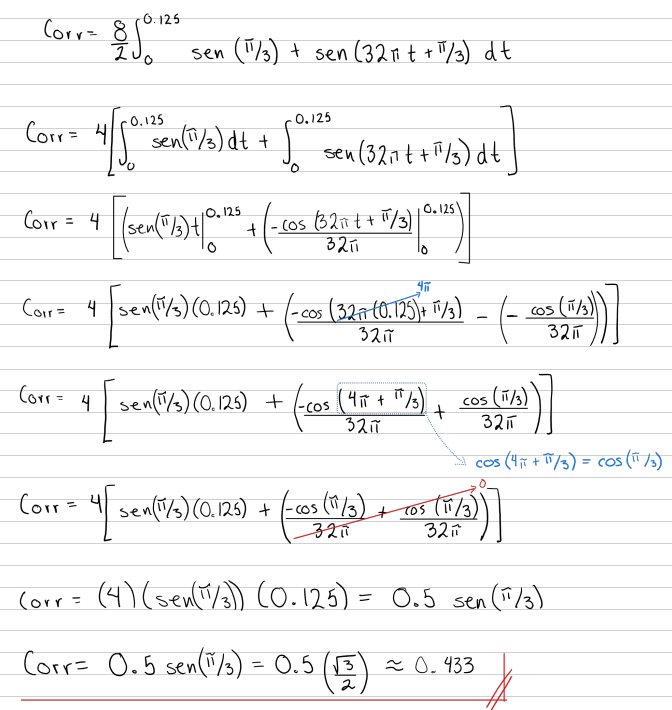

### f) Considering the responses obtained using both sine and cosine references, explain why both are useful when the signal phase is unknown.

Ambas son útiles porque si se busca una frecuencia usando solamente una señal seno, y la señal original resulta estar desfasada $90^\circ$ (como un coseno puro), la fórmula de correlación da cero. Esto genera un falso negativo, haciéndonos creer que la frecuencia no existe.

Al usar las 2 referencias, es como ver la onda desde 2 ángulos distintos: lo que se le escapaba al seno por el desfase, se ve con el coseno.

Si combinamos las respuestas con el Teorema de Pitágoras:
* Señal $x_1(t)$ (sin desfase): $\sqrt{0.5^2 + 0^2} = \mathbf{0.5}$
* Señal $x_2(t)$ (desfase $\pi/3$): $\sqrt{0.25^2 + 0.433^2} = \mathbf{0.5}$

Vemos que el efecto del desfase desaparece y nos da el mismo resultado para ambos casos ($0.5$), demostrando que usar las 2 referencias nos permite detectar la frecuencia correctamente, sin importar la fase desconocida en la que inicie la onda.

# Excercise 9: Frequency detection in white Gaussian noise

Generate and analyze the sampled signal:

$$x[n] = \sin(2\pi \cdot 6n/f_s) + 0.7 \sin(2\pi \cdot 15n/f_s) + w[n]$$

using $f_s = 100$ Hz. Here $w[n]$ denotes zero-mean white Gaussian noise with a selected standard deviation $\sigma$.

In [38]:
frecuencia_muestreo = 100  # Frecuencia de muestreo en Hz
duracion = 2  # Duración en segundos
tiempo = np.arange(0, duracion, 1/frecuencia_muestreo)
muestras = np.arange(len(tiempo))

senal_limpia = np.sin(2 * np.pi * 6 * muestras / frecuencia_muestreo) + 0.7 * np.sin(2 * np.pi * 15 * muestras / frecuencia_muestreo)

desviacion_estandar_base = 1.0

# Generamos el ruido blanco Gaussiano con media 0
ruido = np.random.normal(0, desviacion_estandar_base, len(tiempo))

senal_ruidosa = senal_limpia + ruido

### a) Plot the clean signal and the noisy signal.

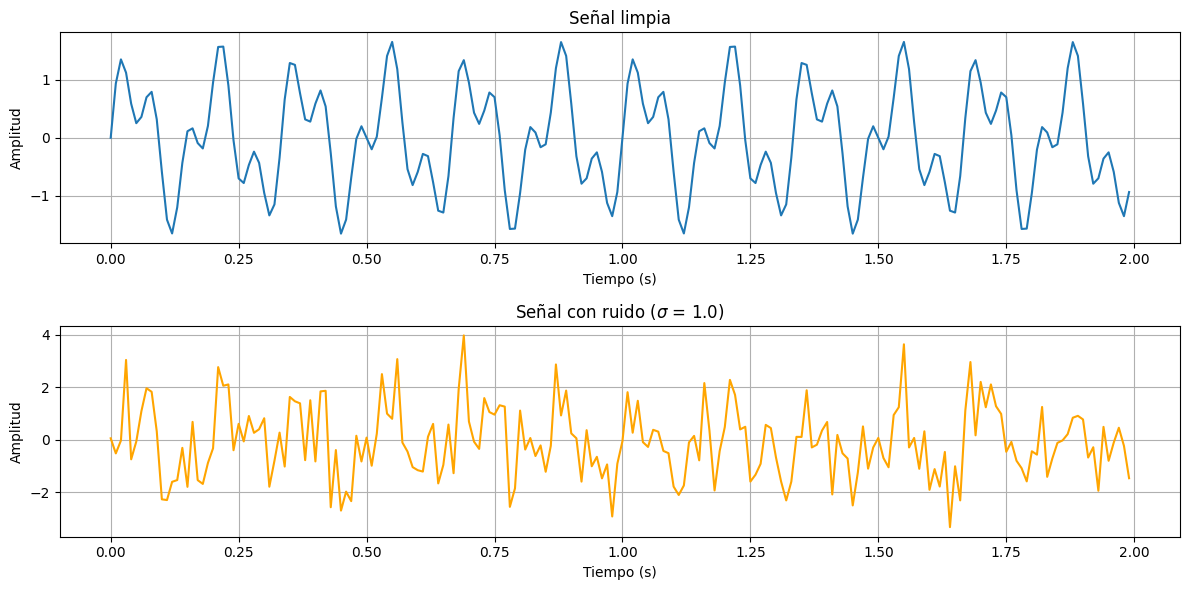

In [39]:
plt.figure(figsize=(12, 6))

# Subgráfica para la señal original (sin ruido)
plt.subplot(2, 1, 1)
plt.plot(tiempo, senal_limpia)
plt.title('Señal limpia')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Subgráfica para la señal contaminada con ruido blanco Gaussiano
plt.subplot(2, 1, 2)
plt.plot(tiempo, senal_ruidosa, color='orange')
plt.title(rf'Señal con ruido ($\sigma$ = {desviacion_estandar_base})')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

### b) Test reference frequencies from 1 to 20 Hz.

In [40]:
frecuencias_candidatas = np.arange(1, 21)

print(f"Frecuencias de prueba: \n{frecuencias_candidatas} Hz")

Frecuencias de prueba: 
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20] Hz


### c) Calculate the correlation response for every candidate frequency.

In [41]:
magnitudes_correlacion = []

# Iteramos sobre el arreglo de frecuencias candidatas (del 1 al 20 Hz)
for frecuencia in frecuencias_candidatas:
  seno_referencia = np.sin(2 * np.pi * frecuencia * tiempo)

  retrasos_seno, correlacion_seno_completa = correlacion_cruzada(
    senal_ruidosa, seno_referencia
  )

  # valor exacto donde el retraso es cero (lag = 0)
  valor_seno = abs(
    correlacion_seno_completa[retrasos_seno == 0][0]
    if 0 in retrasos_seno else 0
  )
  magnitudes_correlacion.append(valor_seno)

magnitudes_correlacion = np.array(magnitudes_correlacion)

### d) Plot correlation magnitude versus frequency.

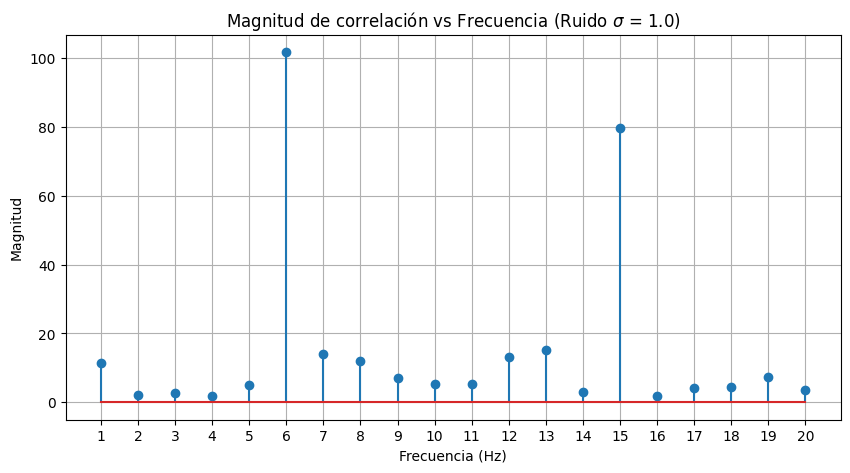

In [42]:
plt.figure(figsize=(10, 5))

plt.stem(frecuencias_candidatas, magnitudes_correlacion)

plt.title(rf'Magnitud de correlación vs Frecuencia (Ruido $\sigma$ = {desviacion_estandar_base})')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')

# Forzamos a que el eje X muestre todas las marcas del 1 al 20 para leerlo más fácil
plt.xticks(frecuencias_candidatas)
plt.grid(True)

plt.show()

### e) Determine whether the frequencies 6 Hz and 15 Hz can still be detected.

Sí, con este nivel de ruido ($\sigma = 1.0$), las frecuencias de 6 Hz y 15 Hz aún pueden detectarse claramente. Observando la gráfica generada en el paso anterior, las magnitudes de correlación muestran picos prominentes exactamente en **6 Hz** y **15 Hz**. Estos picos sobresalen significativamente por encima del piso de ruido aleatorio producido por las otras frecuencias evaluadas, lo que hace que su detección sea totalmente confiable.

### f) Repeat for at least three different values of $\sigma$ and discuss what happens as the noise level increases.


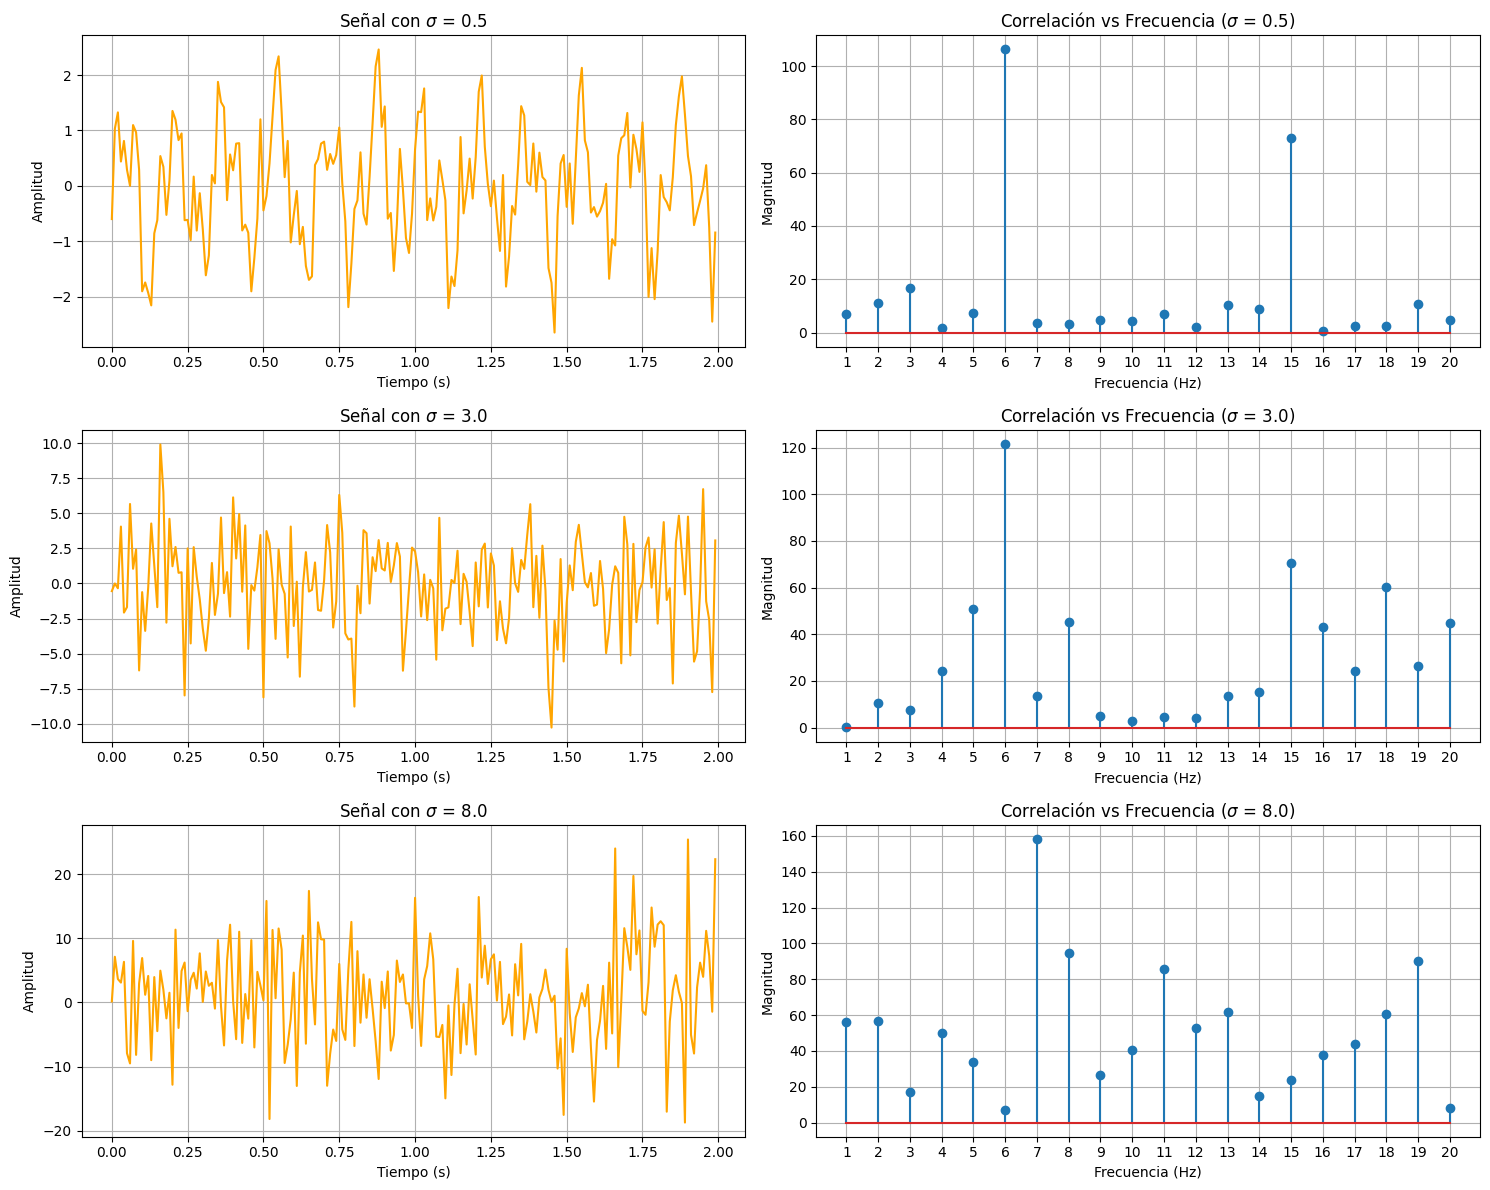

In [43]:
# tres niveles de ruido: bajo, medio y  alto
desviaciones_a_probar = [0.5, 3.0, 8.0]

plt.figure(figsize=(15, 12))

for i, desviacion_actual in enumerate(desviaciones_a_probar):
  # Generamos un nuevo ruido aleatorio y creamos una nueva señal con el ruido
  ruido_actual = np.random.normal(0, desviacion_actual, len(tiempo))
  senal_ruidosa_actual = senal_limpia + ruido_actual

  magnitudes = []

  # Recalculamos la correlación simplificada para las 20 frecuencias
  for frecuencia in frecuencias_candidatas:
    seno_referencia = np.sin(2 * np.pi * frecuencia * tiempo)

    retrasos_seno, correlacion_seno_completa = correlacion_cruzada(
      senal_ruidosa_actual, seno_referencia
    )

    valor_seno = abs(
      correlacion_seno_completa[retrasos_seno == 0][0]
      if 0 in retrasos_seno else 0
    )

    magnitudes.append(valor_seno)

  plt.subplot(3, 2, 2*i + 1)
  plt.plot(tiempo, senal_ruidosa_actual, color='orange')
  plt.title(rf'Señal con $\sigma$ = {desviacion_actual}')
  plt.xlabel('Tiempo (s)')
  plt.ylabel('Amplitud')
  plt.grid(True)

  plt.subplot(3, 2, 2*i + 2)
  plt.stem(frecuencias_candidatas, magnitudes)
  plt.title(rf'Correlación vs Frecuencia ($\sigma$ = {desviacion_actual})')
  plt.xlabel('Frecuencia (Hz)')
  plt.ylabel('Magnitud')
  plt.xticks(frecuencias_candidatas)
  plt.grid(True)

plt.tight_layout()
plt.show()

**Discusión:**

A medida que aumenta el nivel de ruido (desviación estándar $\sigma$), el ruido se distribuye de forma aleatoria entre las diferentes frecuencias, haciendo que los valores de la correlación sean cada vez más altos.

* **Con ruido bajo ($\sigma = 0.5$):** Los picos en 6 Hz y 15 Hz se ven claramente y son fáciles de identificar. La detección es sencilla.

* **Con ruido moderado ($\sigma = 3.0$):** El ruido aumenta y aparecen algunos picos pequeños en otras frecuencias por casualidad, pero las frecuencias originales siguen siendo las más altas.

* **Con ruido extremo ($\sigma = 8.0$):** El ruido es mucho mayor que la señal original. Aparecen picos altos en frecuencias aleatorias que pueden ser iguales o incluso mayores que los picos reales de 6 Hz y 15 Hz. En este punto, el detector falla porque ya no es posible distinguir claramente la señal original del ruido.


# Excercise 10: Build a frequency detector

Design a Python function:

`detect_frequencies(x, fs, frequencies)`

The function must receive a sampled signal x, sampling frequency fs, and a list of candidate frequencies, and return a measure of the presence of every candidate frequency.

Test it using:

$$x(t) = 1.5 \sin(2\pi \cdot 4t) + 0.7 \sin(2\pi \cdot 9t + \pi/4) + 2 \sin(2\pi \cdot 16t - \pi/3)$$

In [44]:
def detect_frequencies(x, fs, frequencies):
  N = len(x) # Numero de Muestras que tiene la señal
  t_internal = np.arange(N) / fs # Tiempo de Cada Muestra
  responses = []

  for f in frequencies:
    # Generacion Señales de referencia
    ref_sin = np.sin(2 * np.pi * f * t_internal)
    ref_cos = np.cos(2 * np.pi * f * t_internal)

    # Correlacion de la la señal contra ambas referencias
    lags_sin, corr_sin_full = correlacion_cruzada(x, ref_sin)
    lags_cos, corr_cos_full = correlacion_cruzada(x, ref_cos)

    # Extraemos el valor de la correlación en el instante cero (lag = 0)
    val_sin = corr_sin_full[lags_sin == 0][0] if 0 in lags_sin else 0
    val_cos = corr_cos_full[lags_cos == 0][0] if 0 in lags_cos else 0

    # Calculamos la magnitud total
    magnitude = np.sqrt(val_sin**2 + val_cos**2)
    responses.append(magnitude)

  return np.array(responses)

frecuencia_muestreo = 100
tiempo_prueba = np.arange(0, 2, 1/frecuencia_muestreo) # 2s de duracion

# Definiendo la señal de prueba proporcionada
senal_prueba = (1.5 * np.sin(2 * np.pi * 4 * tiempo_prueba) +
                0.7 * np.sin(2 * np.pi * 9 * tiempo_prueba + np.pi/4) +
                2.0 * np.sin(2 * np.pi * 16 * tiempo_prueba - np.pi/3))

### a) Search frequencies from 1 to 20 Hz.

In [45]:
frecuencias_busqueda = np.arange(1, 21)
respuesta_detector = detect_frequencies(senal_prueba, frecuencia_muestreo, frecuencias_busqueda)

### b) Plot the original signal.

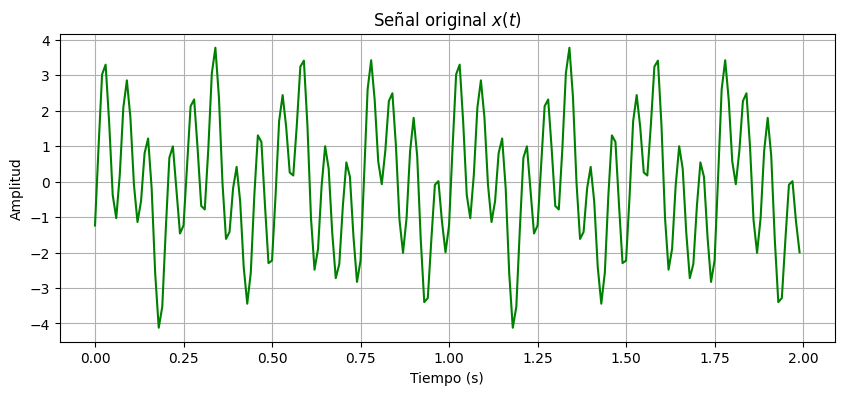

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(tiempo_prueba, senal_prueba, color='green')
plt.title('Señal original $x(t)$')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

### c) Plot detector response versus frequency.

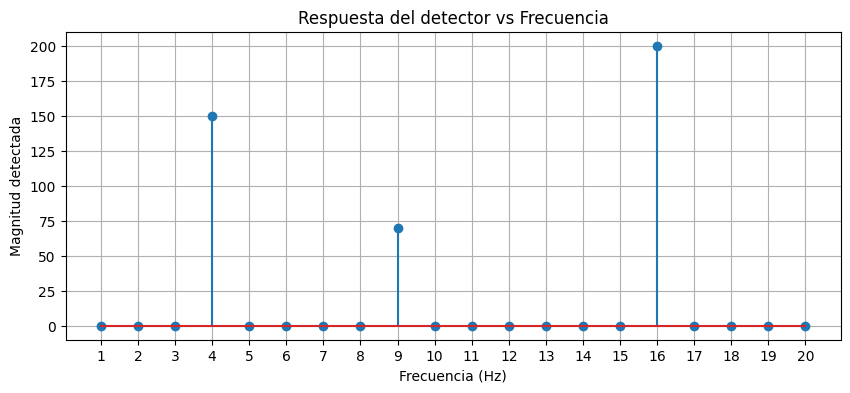

In [47]:
plt.figure(figsize=(10, 4))
plt.stem(frecuencias_busqueda, respuesta_detector)
plt.title('Respuesta del detector vs Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud detectada')
plt.xticks(frecuencias_busqueda)
plt.grid(True)
plt.show()

### d) Identify the three dominant frequencies.

In [48]:
# Juntamos cada frecuencia con su magnitud detectada
pares_frecuencia_respuesta = list(zip(frecuencias_busqueda, respuesta_detector))

# Ordenamos de mayor a menor según la magnitud detectada
pares_frecuencia_respuesta.sort(key=lambda elemento: elemento[1], reverse=True)

# Tomamos las 3 frecuencias con mayor magnitud
tres_primeras = pares_frecuencia_respuesta[:3]

print("d) Las tres frecuencias dominantes identificadas son:")
for frecuencia, magnitud in tres_primeras:
  print(f"   - {frecuencia} Hz")

d) Las tres frecuencias dominantes identificadas son:
   - 16 Hz
   - 4 Hz
   - 9 Hz


### e) Rank them according to their detected strength.

In [49]:
print("e) Orden de acuerdo a su magnitud detectada:")
for posicion, (frecuencia, magnitud) in enumerate(tres_primeras, 1):
  print(f"   Posición {posicion}: {frecuencia} Hz (Magnitud detectada: {magnitud:.2f})")

e) Orden de acuerdo a su magnitud detectada:
   Posición 1: 16 Hz (Magnitud detectada: 200.00)
   Posición 2: 4 Hz (Magnitud detectada: 150.00)
   Posición 3: 9 Hz (Magnitud detectada: 70.00)


### f) Explain why a detector using both sine and cosine references is preferable to one using only sine.

Un detector que usa solo una referencia de seno depende mucho de la **fase** de la señal de entrada. Por ejemplo, si la señal que queremos detectar tiene un desfase de $90^\circ$ (por lo que se convierte en un coseno), al compararla únicamente con nuestra referencia de seno, las partes positivas y negativas se pueden cancelar entre sí, dando como resultado un valor cercano a cero. El detector podría fallar y decir que esa frecuencia no está presente.

Al usar referencias tanto de seno como de coseno (conocido como análisis en cuadratura o I/Q), podemos comparar la señal desde dos posiciones diferentes. Después, calculamos la magnitud usando el Teorema de Pitágoras ($\sqrt{\text{corr}*{\sin}^2 + \text{corr}*{\cos}^2}$). De esta forma, el detector ya no depende de la **fase** de la señal y puede detectar correctamente la frecuencia, sin importar el desfase con el que llegue la onda
